# Setup

In [1]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import pandas as pd
import pypsa
import yaml
import numpy as np
import math

with open(f"../config/plotting.default.yaml") as f:
    pypsa_config = yaml.safe_load(f)

with open(f"minerals_config.yaml") as f:
    techs_map = yaml.safe_load(f)

tech_colors = pypsa_config["plotting"]["tech_colors"]
nice_names = pypsa_config["plotting"]["nice_names"]

all_minerals = ['Aluminium', 'Cobalt', 'Copper', 'Dysprosium', 'Gallium', 'Germanium', 'Graphite', 'Iridium', 'Lithium', 'Manganese', 'Neodymium', 'Nickel', 'Praseodymium', 'Platinum', 'Vanadium']
rare_earths = ['Neodymium', 'Praseodymium', 'Dysprosium']
iea_minerals = ['Copper', 'Cobalt', 'Lithium', 'Nickel', 'REE', 'Graphite']

# paths for EV data calculation
TRANSPORT_DATA_PATH = "../resources/eur_all_countries/transport_data.csv"
POPULATION_DATA_PATH = pd.read_csv("../resources/eur_all_countries/pop_layout_base_s_40.csv")

In [2]:
minerals_color_map = {
    'Lithium': "#ff7f00", 
    'Cobalt': "#a6cee3", 
    "Copper": "#fb9a99", 
    "Nickel": "black", 
    "Graphite (natural and synthetic)": "#303234", 
    "Graphite": "#303234",
    "REE": "#b15928", 
    "Magnet rare earth elements": "#b15928", 
    "Dysprosium": "#b15928", 
    "Neodymium": "#b15928",
    "Gallium": "#ffff99", 
    "Germanium": "#6a3d9a", 
    "Iridium": "#33a02c", 
    "Manganese": "#fdbf6f", 
    "Vanadium": "#e31a1c", 
    "Platinum": "blue",
    "Indium": "#cab2d6"  
}

In [3]:
tech_colors["battery electric vehicles"] = tech_colors["BEV charger"]
tech_colors["other"] = "#454545"
tech_colors["building heat demand"] = tech_colors["heat"]
tech_colors["ambient heat"] = tech_colors["heat pump"]
tech_colors["residential electricity demand"] = "#72709c"
tech_colors["industry electricity demand"] = tech_colors["electricity"]
tech_colors["hydrogen demand"] = tech_colors["land transport fuel cell"]
tech_colors["agriculture machinery"] = tech_colors["land transport fuel cell"]
# tech_colors["methane demand"] = tech_colors["helmeth"]
tech_colors["liquid hydrocarbon demand"] = tech_colors["kerosene for aviation"]
tech_colors["aviation fuels"] = tech_colors["kerosene for aviation"]
tech_colors["shipping fuels"] = tech_colors["shipping methanol"]
tech_colors["biomass demand"] = tech_colors["biogas"]
tech_colors["biogas upgrading"] = tech_colors["biogas"]
tech_colors["hydrogen for industry"] = tech_colors["H2 for industry"]
tech_colors["hydrogen-to-power/heat"] = tech_colors["gas-to-power/heat"]
tech_colors["hydrogen for land transport"] = "#8487e8"

In [4]:
# set matplotlib design 

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

## Functions

In [5]:
# EV share pathway from config (can be replaced by reading YAML)
land_transport_electric_share = {
    2020: 0.0,
    2025: 0.05,
    2030: 0.20,
    2035: 0.45,
    2040: 0.70,
    2045: 0.85,
    2050: 1.0,
}

# Assumptions
start_year = 2025  # set to your "now"
end_year = 2050
ev_lifetime_years = 15


# function that calculates stock of EVs by year, given the electric share, and returns the total EVs sold between start year and end year
def get_total_EVs(start_year, end_year, ev_lifetime_years, land_transport_electric_share):

    # Build annual EV share series via linear interpolation
    share_points = pd.Series(land_transport_electric_share, dtype=float).sort_index()
    years = np.arange(start_year, end_year + 1)
    share_annual = share_points.reindex(np.arange(share_points.index.min(), end_year + 1))
    share_annual = share_annual.interpolate("linear").ffill().bfill().loc[years]

    # Baseline fleet size from transport data (energy_totals_year=2023 in default config)
    # nodal_transport_data = build_nodal_transport_data(TRANSPORT_DATA_PATH, POPULATION_DATA_PATH, 2023)
    transport_data = pd.read_csv(TRANSPORT_DATA_PATH, index_col=[0, 1])
    td = transport_data.xs(2023, level="year")
    fleet_total_2023 = td["number cars"].sum()

    # Keep total fleet constant unless you have a separate fleet-growth series
    fleet = pd.Series(fleet_total_2023, index=years, dtype=float)

    # Target EV stock each year
    ev_stock = share_annual * fleet

    # Stock-turnover model with fixed retirement age
    # sales[t] = stock increase + retirements at t, where retirements[t] = sales[t-lifetime]
    sales = pd.Series(0.0, index=years)
    retirements = pd.Series(0.0, index=years)

    for i, y in enumerate(years):
        # get target EV stock from the previous year
        prev_stock = ev_stock.iloc[i - 1] if i > 0 else 0.0

        # get needed increase in stock to get to target share
        stock_increase = max(ev_stock.loc[y] - prev_stock, 0.0)

        # replacement sales needed 
        repl = sales.loc[y - ev_lifetime_years] if (y - ev_lifetime_years) in sales.index else 0.0

        retirements.loc[y] = repl
        sales.loc[y] = stock_increase + repl

    results_ev_turnover = pd.DataFrame(
        {
            "ev_share": share_annual,
            "fleet_total": fleet,
            "ev_stock": ev_stock,
            "retirements": retirements,
            "ev_sales": sales,
            "ev_sales_cumulative": sales.cumsum(),
        }
    )

    total_ev_sold_2026_2050 = results_ev_turnover["ev_sales"].sum()
    # print(f"Estimated total EVs sold ({start_year}-{end_year}): {total_ev_sold_2026_2050:,.0f}")
    return results_ev_turnover, total_ev_sold_2026_2050

In [6]:
def compute_ev_mineral_usage(start_year, end_year, ev_lifetime_years, land_transport_electric_share, minerals, scenario, mineral_intensities=None, techs=None):
    # EV battery size in MWh, according to the config file
    BEV_battery_size = 0.05


    # get transport data from resources file
    results_ev_turnover, total_cars = get_total_EVs(start_year, end_year, ev_lifetime_years, land_transport_electric_share)

    evs_capacity_df = pd.DataFrame({'component': ['Store', 'Store'], 'carrier': ['EV motor', 'EV battery'], 'capacity': [total_cars, total_cars*BEV_battery_size]})

    # merge with LCI data
    # need to remove EV batteries from regular mineral computation so it's not double counted

    evs_merged = pd.merge(evs_capacity_df, techs, left_on="carrier", right_on="PyPSA technology", how="inner")
    evs_merged = pd.merge(evs_merged, mineral_intensities, left_on="LCI name", right_on="Activity", how="inner")

    evs_merged = evs_merged.rename(columns={'capacity': 'carrier capacity'})
    evs_merged['Sub tech capacity'] = evs_merged['carrier capacity'].mul(evs_merged[scenario], axis=0)
    evs_merged[minerals] = evs_merged[minerals].mul(evs_merged['Sub tech capacity'], axis=0)



    return evs_merged

    # df = pd.concat([df, evs_merged], ignore_index=True)

In [7]:
def compute_mineral_usage(
    network_key,
    n,
    minerals,
    scenario, 
    mineral_intensities=None,
    techs=None,
    capacity_col_name="capacity",
    verbose=False,
    evs=True
):
    """
    Return (df_merged, totals_series) for a given network in dict n.

    - df_merged: expanded capacities merged with intensity data. Contains mineral columns
                 multiplied by capacity (absolute mineral amount per row).
    - totals_series: Series indexed by mineral names with total mineral demand (units: same as conversion below).

    Behavior / assumptions:
    - Uses `n[network_key].statistics.expanded_capacity()` and expects capacity in column 0 (renamed to 'capacity').
    - If techs_map is provided, maps carriers via techs_map[lci_map_key] into column 'lci_technology'.
    - Tries to merge intensity data:
         * primary: merge mineral_intensities on left_on='lci_technology' or provided name -> right_on='Activity'
         * fallback: merge mineral_intensities_carrara on left_on='Other source name' -> right_on='Technology'
      Coalesces mineral columns preferring the primary source.
    - Returns totals in Mt if you divide by 1e9 (the code below returns totals_in_Mt).
    """

    # only want ENERGY CAPACITY (ignore other carriers like co2, heat...)
    elec_carriers = ['AC', 'DC', 'Battery Storage', 'home battery', 'low voltage', 'EV battery', 'Battery Storage', 'battery']

    # 1) expanded capacities
    df = pd.DataFrame(n[network_key].statistics.expanded_capacity(bus_carrier=elec_carriers).reset_index()).rename(columns={0: capacity_col_name})

    # muptiply the H2 capacity by -1 (because it is electrical input not output)
    df.loc[df['carrier'] == 'H2 Electrolysis', capacity_col_name] *= -1

    # rename different heat pump types to "heat pump"
    hp_carriers = ['residential rural air heat pump',
    'residential rural ground heat pump',
    'residential urban decentral air heat pump',
    'services rural air heat pump',
    'services rural ground heat pump',
    'services urban decentral air heat pump',
    'urban central air heat pump']

    df['carrier_renamed'] = np.where(
        df['carrier'].isin(hp_carriers),
        'heat pump',
        df['carrier']
        )

    # use optimal battery capacity, not expanded
    # df_opt = pd.DataFrame(n[network_key].statistics.installed_capacity(bus_carrier=elec_carriers).reset_index()).rename(columns={0: capacity_col_name})
    # df.loc[df['carrier'] == 'EV battery', 'capacity'] = df_opt[df_opt['carrier']=='EV battery']['capacity'].values[0]


    df = pd.merge(df, techs, left_on="carrier_renamed", right_on="PyPSA technology", how="inner")

    df = pd.merge(df, mineral_intensities, left_on="LCI name", right_on="Activity", how="inner")

    # 6) compute absolute mineral use per row: intensity * capacity
    # Note: intensity units must match this multiplication. Adjust conversion factor as needed.
    df = df.rename(columns={'capacity': 'carrier capacity'})
    df['Sub tech capacity'] = df['carrier capacity'].mul(df[scenario], axis=0)
    df[minerals] = df[minerals].mul(df['Sub tech capacity'], axis=0)

    # remove EV battery capacity because we calculate it manually
    df = df[df['carrier_renamed']!='EV battery']

    # separate process for EVs: 
    if evs:  
        evs_merged = compute_ev_mineral_usage(2025, 2050, 15, land_transport_electric_share, minerals, scenario, mineral_intensities, techs)
        df = pd.concat([df, evs_merged], ignore_index=True)


    # combine offwind columns 
    offwind_carriers = ['Offshore Wind (AC)', 'Offshore Wind (DC)']
    df['carrier_renamed'] = np.where(
        df['carrier_renamed'].isin(offwind_carriers),
        'Offshore wind',
        df['PyPSA technology']
        )


    # 7) aggregate totals (convert to Mt: divide by 1e9)

    totals_Mt = df[minerals].sum() / 1e9

    if verbose:
        print(f"Network {network_key}: merged rows {len(df)}; minerals found from sources: {', '.join([m for m in minerals if not df[m].isna().all()])}")

    return df, totals_Mt


def compare_networks(
    network_keys,
    n,
    minerals,
    techs,
    mineral_intensities=None,
    show_plot=True,
    figsize=(12,6),
):
    """
    Compute mineral totals for multiple network keys and return a DataFrame of totals (minerals x networks).
    Also plots a side-by-side bar chart comparing totals (Mt).
    """
    results = {}
    details = {}

    for k in network_keys:
        dfk, tot = compute_mineral_usage(
            k,
            n,
            minerals,
            mineral_intensities,
            techs 
        )
        results[k] = tot
        details[k] = dfk

    comparison = pd.DataFrame(results)

    if show_plot:
        # Optionally sort minerals by total across networks (largest minerals shown first in legend)
        comparison = comparison.loc[comparison.sum(axis=1).sort_values(ascending=False).index]

        # Transpose so rows = networks, columns = minerals and plot stacked bars
        stack_df = comparison.T  # index: networks, columns: minerals

        ax = stack_df.plot.bar(stacked=True, figsize=figsize, colormap='tab20')
        ax.set_ylabel("Mineral use [Mt]")
        ax.set_xlabel("Network")
        ax.set_title("Mineral demand breakdown per network")
        plt.xticks(rotation=0)
        ax.legend(title="Mineral", bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    return comparison, details

In [8]:
def stacked_barh_signed(
    data,
    ax,
    *,
    tech_colors=None,
    nice_names=None,
    y_label="Total",
    group_labels=None,
    annotate_thresh=0.03,
    annotate_decimals=0,
    title=None,
    group_bracket_height=0.15,  # Height above bar for group brackets
    bar_height=0.6,
    group_label_font_size=9,
    show_legend=True,
):
    """
    Plot horizontal stacked bars robust to negative values.

    Parameters
    ----------
    - data: pandas Series OR dict of Series
      - If Series with MultiIndex: single stacked bar with grouped bracket annotations
      - If Series with single index: single stacked bar (original behavior)
      - If dict: single stacked bar with grouped bracket annotations above
    - ax: matplotlib axis
    - tech_colors: dict carrier -> color (fallback '#888888')
    - nice_names: dict carrier -> pretty label
    - y_label: str, text for the y-axis label
    - group_labels: dict {group_key: label}, nice labels for group annotations (for dict/MultiIndex data)
    - annotate_thresh: fraction threshold for showing labels
    - annotate_decimals: number of decimal places for annotations (default 0)
    - title: optional plot title
    - group_bracket_height: vertical offset for group bracket annotations
    - bar_height: height of the bar
    - show_legend: bool, whether to display the legend (default True)
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Check if data is MultiIndex Series
    is_multiindex = isinstance(data, pd.Series) and isinstance(data.index, pd.MultiIndex)

    # Handle both Series and dict inputs
        # NEW: multiple bars if DataFrame (rows=scenarios, cols=carriers)
    if isinstance(data, pd.DataFrame):
        legend_handles = {}
        y_positions = np.arange(len(data.index))

        for y_pos, (_, row) in enumerate(data.iterrows()):
            _plot_single_bar(
                row.fillna(0.0),
                ax,
                y_pos,
                tech_colors,
                nice_names,
                annotate_thresh,
                bar_height,
                legend_handles,
                annotate_decimals,
            )

        ax.set_yticks(y_positions)
        ax.set_yticklabels([str(x) for x in data.index])
        ax.set_ylabel("Scenario")
        ax.invert_yaxis()  # optional: first scenario at top

        if title:
            ax.set_title(title, pad=20)

        if show_legend and legend_handles:
            ax.legend(
                handles=list(legend_handles.values()),
                title="Carrier",
                bbox_to_anchor=(1.05, 1),
                loc="upper left",
            )
        return
    
    if isinstance(data, dict) or is_multiindex:
        # Single stacked bar with group annotations
        legend_handles = {}

        # Track cumulative positions for positive and negative values separately
        left_pos_positive = 0.0  # Tracks rightward stacking from 0
        left_pos_negative = 0.0  # Tracks leftward stacking from 0

        # Store group boundaries separately for positive and negative portions
        # {group_key: {'pos': (start_x, end_x), 'neg': (start_x, end_x)}}
        group_boundaries = {}

        if is_multiindex:
            # Get unique group keys from first level
            group_keys = data.index.get_level_values(0).unique()
        else:
            # Dict case
            group_keys = data.keys()

        for group_key in group_keys:
            # Extract series for this group
            if is_multiindex:
                series = data.xs(group_key, level=0)
            else:
                series = data[group_key]

            series = series.dropna()

            # Split into positive and negative values (keep zeros with positives)
            pos_series = series[series >= 0].sort_values(ascending=False)
            neg_series = series[series < 0].sort_values(ascending=True)  # Sort ascending for leftward stacking

            # Initialize boundaries for this group
            group_boundaries[group_key] = {'pos': None, 'neg': None}

            # --- Handle positive values (stack rightward) ---
            if len(pos_series) > 0:
                group_start_pos = left_pos_positive
                total_pos = pos_series.sum()

                for carrier, value in pos_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_positive, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_pos > 0 and (value / total_pos) >= annotate_thresh:
                        ax.text(
                            left_pos_positive + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_positive += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['pos'] = (group_start_pos, left_pos_positive)

            # --- Handle negative values (stack leftward) ---
            if len(neg_series) > 0:
                group_start_neg = left_pos_negative
                total_neg_abs = abs(neg_series.sum())

                for carrier, value in neg_series.items():
                    color = tech_colors.get(carrier, "#888888")
                    label = nice_names.get(carrier, carrier)

                    ax.barh(
                        0, value, left=left_pos_negative, height=bar_height, 
                        color=color, edgecolor="white"
                    )

                    # Annotate if above threshold
                    if total_neg_abs > 0 and (abs(value) / total_neg_abs) >= annotate_thresh:
                        ax.text(
                            left_pos_negative + value / 2,
                            0,
                            f"{value:.{annotate_decimals}f}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

                    left_pos_negative += value

                    # Add to legend (avoid duplicates)
                    if label not in legend_handles:
                        legend_handles[label] = mpatches.Patch(color=color, label=label)

                group_boundaries[group_key]['neg'] = (left_pos_negative, group_start_neg)

        # Draw group brackets/annotations
        y_bracket_pos = bar_height / 2 + group_bracket_height  # Above bar
        y_bracket_neg = -bar_height / 2 - group_bracket_height  # Below bar

        for group_key, boundaries in group_boundaries.items():
            group_label = group_labels.get(group_key, group_key)

            # Draw positive bracket (above bar)
            if boundaries['pos'] is not None:
                x_start, x_end = boundaries['pos']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_pos, y_bracket_pos],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_pos - tick_height, y_bracket_pos + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label above bracket
                    ax.text(
                        x_mid,
                        y_bracket_pos + 0.08,
                        group_label,
                        ha="center",
                        va="bottom",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

            # Draw negative bracket (below bar)
            if boundaries['neg'] is not None:
                x_start, x_end = boundaries['neg']
                if x_end - x_start > 1e-6:  # Skip empty groups
                    x_mid = (x_start + x_end) / 2

                    # Draw horizontal line (bracket)
                    ax.plot(
                        [x_start, x_end],
                        [y_bracket_neg, y_bracket_neg],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Draw vertical ticks at ends
                    tick_height = 0.04
                    ax.plot(
                        [x_start, x_start],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )
                    ax.plot(
                        [x_end, x_end],
                        [y_bracket_neg - tick_height, y_bracket_neg + tick_height],
                        color='black',
                        linewidth=1.5,
                        clip_on=False
                    )

                    # Add group label below bracket
                    ax.text(
                        x_mid,
                        y_bracket_neg - 0.08,
                        group_label,
                        ha="center",
                        va="top",
                        fontsize=group_label_font_size,
                        fontweight="normal",
                        clip_on=False
                    )

        # Set axis properties
        ax.set_yticks([0])
        ax.set_yticklabels([y_label])
        ax.axvline(0, color="k", lw=0.8, alpha=0.4)

        # Set x-limits with padding for both positive and negative
        xmax = left_pos_positive
        xmin = left_pos_negative
        pad = 0.05 * max(abs(xmax), abs(xmin), 1e-12)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Adjust y-limits to show both upper and lower brackets
        ax.set_ylim(y_bracket_neg - 0.25, y_bracket_pos + 0.25)

    if title:
        ax.set_title(title, pad=20)

    # Create legend from collected handles
    if show_legend and legend_handles:
        ax.legend(
            handles=list(legend_handles.values()),
            title="Carrier",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )


def _plot_single_bar(
    s, ax, y_pos, tech_colors, nice_names, annotate_thresh, bar_height, legend_handles, annotate_decimals=0
):
    """Helper function to plot a single stacked bar at given y position."""
    s = s.dropna()
    pos = s[s > 0].sort_values(ascending=False)
    neg = s[s < 0].sort_values()

    total_pos = pos.sum()
    total_neg_abs = (-neg).sum()

    left_pos = 0.0
    left_neg = 0.0

    # Plot positives (to the right)
    for key, v in pos.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_pos, height=bar_height, color=color, edgecolor="white"
        )

        if total_pos > 0 and (v / total_pos) >= annotate_thresh:
            ax.text(
                left_pos + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_pos += v

        # Add to legend (avoid duplicates)
        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Plot negatives (to the left)
    for key, v in neg.items():
        color = tech_colors.get(key, "#888888")
        label = nice_names.get(key, key)
        ax.barh(
            y_pos, v, left=left_neg, height=bar_height, color=color, edgecolor="white"
        )

        if total_neg_abs > 0 and ((-v) / total_neg_abs) >= annotate_thresh:
            ax.text(
                left_neg + v / 2,
                y_pos,
                f"{v:.{annotate_decimals}f}",
                ha="center",
                va="center",
                fontsize=8,
            )
        left_neg += v

        if label not in legend_handles:
            legend_handles[label] = mpatches.Patch(color=color, label=label)

    # Draw zero reference line
    ax.axvline(0, color="k", lw=0.8, alpha=0.4, zorder=1)

    # Set x-limits with padding
    xmax = max(0.0, left_pos)
    xmin = min(0.0, left_neg)

    # Update ax limits if needed (don't shrink)
    current_xlim = ax.get_xlim()
    pad = 0.05 * max(xmax, abs(xmin), 1e-12)
    new_xlim = (min(current_xlim[0], xmin - pad), max(current_xlim[1], xmax + pad))
    ax.set_xlim(new_xlim)



def plot_comparison_barh(
    data,
    ax,
    *,
    lower_col=None,
    upper_col=None,
    tech_colors=None,
    nice_names=None,
    group_labels=None,
    xlabel="Value",
    title=None,
    bar_height=0.6,
    group_label_font_size=9,
    marker_size=4,
    show_legend=True,
    annotate_decimals=1,
    annotate_font_size=8,
):
    """
    Plot horizontal bars comparing two columns with group brackets on y-axis.

    Parameters
    ----------
    - data: DataFrame with MultiIndex (group, item) and at least 2 columns for comparison
    - ax: matplotlib axis
    - lower_col: str or int, column name/index for lower bound (shown as 'x' marker). If None, uses first column
    - upper_col: str or int, column name/index for upper bound (shown as full bar). If None, uses second column
    - tech_colors: dict item -> color (fallback '#888888'). Uses second-level index for lookup
    - nice_names: dict item -> pretty label. Uses second-level index for lookup
    - group_labels: dict {group_key: label}, nice labels for group annotations
    - xlabel: str, label for x-axis
    - title: optional plot title
    - bar_height: height of the bars
    - group_label_font_size: font size for group labels
    - marker_size: size of the 'x' marker for lower bound values
    - show_legend: bool, whether to display the legend (default True)
    - annotate_decimals: number of decimal places for bar annotations (default 1)
    - annotate_font_size: font size for bar value annotations (default 8)
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}
    if group_labels is None:
        group_labels = {}

    # Determine which columns to use
    if lower_col is None:
        lower_col = data.columns[0]
    if upper_col is None:
        upper_col = data.columns[1] if len(data.columns) > 1 else data.columns[0]

    # Get unique groups in their original order
    groups = data.index.get_level_values(0).unique()

    # Build y-positions and group boundaries
    y_pos = 0
    group_boundaries = {}
    y_positions = []  # List of (item, y_position, label) tuples

    for group in groups:
        group_data = data.xs(group, level=0)
        group_start = y_pos

        for item in group_data.index:
            label = nice_names.get(item, item)
            y_positions.append((item, y_pos, label))
            y_pos += 1

        group_boundaries[group] = (group_start, y_pos - 1)

    # Calculate max and min values
    df = data[[lower_col, upper_col]]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    max_val = df.max().max()
    min_val = df.min().min()

    if max_val == 0 or pd.isna(max_val):
        max_val = 1  # Avoid division by zero

    # Check if there are any negative values
    has_negative = min_val < 0 if pd.notna(min_val) else False

    # Plot bars
    for item, y, label in y_positions:
        # Find the item in the original dataframe
        # Need to search through all groups to find it
        for group in groups:
            try:
                group_data = data.xs(group, level=0)
                if item in group_data.index:
                    color = tech_colors.get(item, "#888888")

                    lower_val = group_data.loc[item, lower_col]
                    upper_val = group_data.loc[item, upper_col]

                    if np.isinf(upper_val):
                        ax.text(
                            0,
                            y,
                            " Infinity!",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    elif pd.isna(upper_val):
                        ax.text(
                            0,
                            y,
                            " NaN/None",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    elif upper_val == 0:
                        ax.text(
                            upper_val,
                            y,
                            " Not installed",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    else:
                        # Plot upper bound as full opaque bar
                        ax.barh(
                            y,
                            upper_val,
                            height=bar_height,
                            color=color,
                            edgecolor="white",
                            linewidth=0.5,
                        )

                        # Annotate bar with its value to the right
                        ax.text(
                            upper_val,
                            y,
                            f" {upper_val:.{annotate_decimals}f}",
                            ha="left",
                            va="center",
                            fontsize=annotate_font_size,
                        )

                    # Plot lower bound as 'x' marker
                    if pd.notna(lower_val) and np.isfinite(lower_val):
                        ax.plot(
                            lower_val,
                            y,
                            marker="x",
                            color="black",
                            markersize=marker_size,
                            markeredgewidth=1.5,
                            linestyle="",
                        )
                    break
            except KeyError:
                continue

    # Set axis properties first to get proper tick label positions
    y_ticks = [y for _, y, _ in y_positions]
    y_labels = [label for _, _, label in y_positions]

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_ylim(-0.5, y_pos - 0.5)

    # Set x-axis limits
    if has_negative:
        # Has negative values - center around 0
        x_min = min_val - abs(min_val) * 0.05
        x_max = max_val * 1.05
    else:
        # No negative values - start at 0
        x_min = 0
        x_max = max_val * 1.05
    # if np.isinf(x_max):
    #     x_max = 1
    # if np.isinf(x_min):
    #     x_min = 0

    ax.set_xlim(x_min, x_max)

    # Force axis to draw so we can get label positions
    ax.figure.canvas.draw()

    # Get the position of the leftmost edge of the widest y-tick label
    # This will be our reference point for the brackets
    try:
        # Get bounding boxes of y-tick labels in display coordinates
        renderer = ax.figure.canvas.get_renderer()
        bboxes = [
            label.get_window_extent(renderer=renderer) for label in ax.get_yticklabels()
        ]

        if bboxes:
            # Find the leftmost edge among all labels (in display coordinates)
            leftmost_display = min([bbox.x0 for bbox in bboxes])

            # Convert from display to data coordinates
            # We need to transform a point at the left edge of the labels
            inv = ax.transData.inverted()
            # Use the y-coordinate from the middle of the plot
            y_middle_display = sum([bbox.y0 + bbox.y1 for bbox in bboxes]) / (
                2 * len(bboxes)
            )
            leftmost_x = inv.transform([[leftmost_display, y_middle_display]])[0][0]
        else:
            leftmost_x = x_min
    except Exception:
        # Fallback if we can't get label positions
        leftmost_x = x_min

    # Position brackets just to the left of the leftmost label edge
    bracket_offset = (x_max - x_min) * 0.06  # Small offset from labels
    x_bracket_pos = leftmost_x - bracket_offset

    # Draw group brackets on the left
    for group, (y_start, y_end) in group_boundaries.items():
        if y_end >= y_start:  # Skip empty groups
            y_mid = (y_start + y_end) / 2

            # Draw vertical line (bracket)
            ax.plot(
                [x_bracket_pos, x_bracket_pos],
                [y_start - 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )

            # Draw horizontal ticks at ends
            tick_width = (x_max - x_min) * 0.01
            ax.plot(
                [x_bracket_pos - tick_width, x_bracket_pos + tick_width],
                [y_start - 0.5, y_start - 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )
            ax.plot(
                [x_bracket_pos - tick_width, x_bracket_pos + tick_width],
                [y_end + 0.5, y_end + 0.5],
                color="black",
                linewidth=1.5,
                clip_on=False,
            )

            # Add group label to the left of bracket
            group_label = group_labels.get(group, group)
            ax.text(
                x_bracket_pos - tick_width * 1.5,
                y_mid,
                group_label,
                ha="right",
                va="center",
                fontsize=group_label_font_size,
                fontweight="normal",
                clip_on=False,
            )

    ax.set_xlabel(xlabel)

    if title:
        ax.set_title(title)

    # Create custom legend
    if show_legend:
        from matplotlib.lines import Line2D

        legend_elements = [
            mpatches.Patch(facecolor="gray", label=upper_col),
            Line2D(
                [0],
                [0],
                marker="x",
                color="black",
                label=lower_col,
                markersize=marker_size,
                markeredgewidth=1.5,
                linestyle="",
            ),
        ]
        ax.legend(handles=legend_elements, loc="lower right")


In [9]:
def mineral_scenario_comparison_mixed_sources(
    n,
    base_scenario,
    network_scenarios,
    market_scenarios,
    mineral_specs,
    non_energy_col="GDP-adjusted value entso-e (Mt)",
    ncols=3,
    fig_title="",
):
    """Plot stacked mineral demand bars with mineral-specific non-energy and availability sources.
    Each entry in ``mineral_specs`` is a dict with required keys:
      - ``mineral``
      - ``DNEA_source``
      - ``DNEA_year``
      - ``avail_source``
      - ``avail_year``
      - ``avail_method``
    Optional keys per mineral:
      - ``energy_minerals``: list/str of minerals passed to ``compute_mineral_usage``
        (e.g. ["Graphite", "Graphite (synthetic)"] for the combined graphite bar).
      - ``non_energy_mineral``: mineral name used to fetch non-energy demand.
      - ``avail_mineral``: mineral name used to fetch availability.
      - ``color``: bar color override for energy demand segment.
    """

    bar_width = 0.6
    scenario_names = list(network_scenarios) + list(market_scenarios)
    n_scenarios = len(scenario_names)
    n_network = len(network_scenarios)

    n_minerals = len(mineral_specs)
    nrows = math.ceil(n_minerals / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(12, nrows * 2.5 + 1))
    axes = np.array(axs, ndmin=1).flatten()

    def _energy_total_yearly(network_key, market_scenario, energy_minerals):
        _, totals_Mt = compute_mineral_usage(
            network_key,
            n,
            energy_minerals,
            market_scenario,
            mineral_intensities,
            tech_scenarios,
        )
        return float(totals_Mt.sum())

    for idx, spec in enumerate(mineral_specs):
        mineral = spec["mineral"]
        non_energy_mineral = spec.get("non_energy_mineral", mineral)
        avail_mineral = spec.get("avail_mineral", mineral)
        energy_minerals = spec.get("energy_minerals", mineral)

        dnea_mask = (
            (non_energy_demand["Mineral"] == non_energy_mineral)
            & (non_energy_demand["Year"] == spec["DNEA_year"])
            & (non_energy_demand["Source"] == spec["DNEA_source"])
        )
        dnea_series = non_energy_demand.loc[dnea_mask, non_energy_col]
        if dnea_series.empty:
            raise ValueError(
                f"No non-energy demand data for {mineral} with source={spec['DNEA_source']}, year={spec['DNEA_year']}"
            )
        dnea_value = float(dnea_series.iloc[0])

        grid_demand_mask = (
            (grid_demand["Mineral"] == mineral)
            & (grid_demand["Year"] == spec["grid_demand_year"])
        )
        grid_demand_series = grid_demand.loc[grid_demand_mask, "GDP-adjusted value entso-e (Mt)"]
        grid_demand_value = 0
        if not grid_demand_series.empty:
            grid_demand_value = float(grid_demand_series.iloc[0])

        avail_mask = (
            (mineral_avail["Mineral"] == avail_mineral)
            & (mineral_avail["Estimate method"] == spec["avail_method"])
            & (mineral_avail["Estimate year"] == spec["avail_year"])
            & (mineral_avail["Source"] == spec["avail_source"])
        )
        avail_series = mineral_avail.loc[avail_mask, "Value (Mt)"]

        energy_vals = []
        for network_key in network_scenarios:
            energy_vals.append(_energy_total_yearly(network_key, "Market share current", energy_minerals))
        for market_scenario in market_scenarios:
            energy_vals.append(_energy_total_yearly(base_scenario, market_scenario, energy_minerals))

        energy_vals = np.array(energy_vals, dtype=float)
        dnea_vals = np.full(n_scenarios, dnea_value, dtype=float)
        grid_vals = np.full(n_scenarios, grid_demand_value, dtype=float)

        ax = axes[idx]
        energy_color = spec.get("color", minerals_color_map.get(mineral, "#3271a8"))

        ax.bar(scenario_names, dnea_vals, bar_width, label="Non-energy demand", color="#d9d9d9", zorder=2)
        ax.bar(scenario_names, grid_vals, bar_width, bottom=dnea_vals, label="Grid demand", color="#696969", zorder=2)
        ax.bar(
            scenario_names,
            energy_vals,
            bar_width,
            bottom=dnea_vals + grid_vals,
            color=energy_color,
            zorder=2,
        )

        if not avail_series.empty:
            avail_value = float(avail_series.iloc[0])
            min_prod_gdp = avail_value * mineral_alloc_factors["GDP share"]
            min_prod_pc = avail_value * mineral_alloc_factors["Per capita share"]
            min_prod_pce = avail_value * mineral_alloc_factors["Per capita share corrected for energy use"]

            ax.axhline(
                y=min_prod_gdp,
                linestyle="--",
                linewidth=1.5,
                zorder=3,
                color="blue",
                label="GDP-allocated supply",
            )
            ax.axhline(
                y=min_prod_pc,
                linestyle="--",
                linewidth=1.5,
                zorder=3,
                color="orange",
                label="Per-capita-allocated supply",
            )
            ax.axhline(
                y=min_prod_pce,
                linestyle="--",
                linewidth=1.5,
                zorder=3,
                color="green",
                label="Per-capita allocated supply\n(energy-corrected)",
            )

        ax.set_ylabel("Amount (Mt)")
        ax.set_xlabel("Scenario")
        ax.set_title(mineral)
        ax.grid(zorder=0)
        ax.tick_params(axis="x", labelrotation=90)

        # Distinguish network scenarios (left) from market scenarios (right)
        # with a light background tint and a vertical separator.
        # ax.axvspan(-0.5, n_network - 0.5, alpha=0.07, color="steelblue", zorder=0)
        # ax.axvspan(n_network - 0.5, n_scenarios - 0.5, alpha=0.07, color="darkorange", zorder=0)
        # ax.axvline(x=n_network - 0.5, color="gray", linestyle=":", linewidth=0.8, zorder=1)

    # Hide empty subplot axes when mineral count is not a multiple of ncols.
    for ax in axes[n_minerals:]:
        ax.set_visible(False)

    axs_2d = np.atleast_2d(axs)
    n_rows, n_cols = axs_2d.shape
    for i, ax in enumerate(axs_2d.flat):
        if not ax.get_visible():
            continue
        row = i // n_cols
        if row < n_rows - 1:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

    handles, labels = axes[0].get_legend_handles_labels()
    
    # Create a dictionary to get unique labels and handles
    unique_labels = {}
    for handle, label in zip(handles, labels):
        if label not in unique_labels:
            unique_labels[label] = handle

    # network_patch = mpatches.Patch(facecolor="steelblue", alpha=0.4, linewidth=0, label="Technology scenarios")
    # market_patch = mpatches.Patch(facecolor="darkorange", alpha=0.4, linewidth=0, label="Sub-technology scenarios")

    fig.suptitle(fig_title, fontsize=14, y=0.99)
    fig.tight_layout(rect=[0, 0, 0.66, 0.99])

    legend_handles = list(unique_labels.values())
    legend_labels = list(unique_labels.keys())

    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper left",
        bbox_to_anchor=(0.68, 0.95),
        frameon=False,
        borderaxespad=0.0,
        fontsize=10
    )

    plt.show()

In [10]:
def energy_by_tech(network_key, market_scenario, energy_minerals):
        merged, _ = compute_mineral_usage(
            network_key,
            n,
            energy_minerals,
            market_scenario,
            mineral_intensities,
            tech_scenarios,
        )

        mineral_cols = [m for m in _to_list(energy_minerals) if m in merged.columns]
        if not mineral_cols:
            return pd.Series(dtype=float)

        if tech_group_col not in merged.columns:
            raise ValueError(
                f"Column '{tech_group_col}' not found in merged dataframe from compute_mineral_usage."
            )

        # Convert kg to Mt and sum selected mineral columns into one energy value per tech.
        tech_use_mt = merged.groupby(tech_group_col)[mineral_cols].sum().sum(axis=1) / 1e9
        tech_use_mt = tech_use_mt[tech_use_mt != 0].sort_values(ascending=False)
        return tech_use_mt

def mineral_scenario_comparison_mixed_sources_by_technology(
    n,
    base_scenario,
    network_scenarios,
    market_scenarios,
    mineral_specs,
    non_energy_col="GDP-adjusted value entso-e (Mt)",
    grid_demand_year="Cumulative",
    ncols=3,
    fig_title="",
    tech_group_col="carrier_renamed",
    min_tech_share=0.01,
    figwidth=13
):
    """Plot mineral demand bars per scenario with energy demand split by technology.

    This function mirrors ``mineral_scenario_comparison_mixed_sources`` but breaks
    the energy-demand segment into technology contributions using the merged
    dataframe returned by ``compute_mineral_usage``.

    Parameters
    ----------
    - mineral_specs: list of dicts. Required keys per mineral:
      ``mineral``, ``DNEA_source``, ``DNEA_year``, ``avail_source``,
      ``avail_year``, ``avail_method``.
      Optional keys:
      ``energy_minerals``, ``non_energy_mineral``, ``avail_mineral``,
      ``grid_demand_year``.
    - tech_group_col: column used to aggregate technology contribution from
      ``compute_mineral_usage`` merged output.
    - min_tech_share: hide technologies with total contribution smaller than
      this share of total energy demand for each mineral subplot.
    """

    bar_width = 0.8
    scenario_names = list(network_scenarios) + list(market_scenarios)
    n_scenarios = len(scenario_names)
    n_network = len(network_scenarios)

    n_minerals = len(mineral_specs)
    nrows = math.ceil(n_minerals / ncols)
    fig, axs = plt.subplots(nrows, ncols, figsize=(figwidth, nrows * 2.8 + 2))
    axes = np.array(axs, ndmin=1).flatten()

    def _to_list(value):
        if isinstance(value, (list, tuple, np.ndarray, pd.Index)):
            return list(value)
        return [value]

    def _energy_by_tech(network_key, market_scenario, energy_minerals):
        merged, _ = compute_mineral_usage(
            network_key,
            n,
            energy_minerals,
            market_scenario,
            mineral_intensities,
            tech_scenarios,
        )

        mineral_cols = [m for m in _to_list(energy_minerals) if m in merged.columns]
        if not mineral_cols:
            return pd.Series(dtype=float)

        if tech_group_col not in merged.columns:
            raise ValueError(
                f"Column '{tech_group_col}' not found in merged dataframe from compute_mineral_usage."
            )

        # Convert kg to Mt and sum selected mineral columns into one energy value per tech.
        tech_use_mt = merged.groupby(tech_group_col)[mineral_cols].sum().sum(axis=1) / 1e9
        tech_use_mt = tech_use_mt[tech_use_mt != 0].sort_values(ascending=False)
        return tech_use_mt

    inverse_nice_names = {v: k for k, v in nice_names.items()}
    tech_colors_lower = {str(k).strip().lower(): v for k, v in tech_colors.items()}

    def _resolve_tech_color(tech_name):
        if tech_name == "Other":
            return "#000000"

        pretty_name = nice_names.get(tech_name, tech_name)
        candidates = [tech_name, pretty_name, inverse_nice_names.get(tech_name)]

        for cand in candidates:
            if cand is None:
                continue
            if cand in tech_colors:
                return tech_colors[cand]
            cand_lower = str(cand).strip().lower()
            if cand_lower in tech_colors_lower:
                return tech_colors_lower[cand_lower]

        # Neutral fallback only for truly missing keys.
        return "#888888"

    for idx, spec in enumerate(mineral_specs):
        mineral = spec["mineral"]
        print(mineral)
        non_energy_mineral = spec.get("non_energy_mineral", mineral)
        avail_mineral = spec.get("avail_mineral", mineral)
        energy_minerals = spec.get("energy_minerals", mineral)
        local_grid_demand_year = spec.get("grid_demand_year", grid_demand_year)

        dnea_mask = (
            (non_energy_demand["Mineral"] == non_energy_mineral)
            & (non_energy_demand["Year"] == spec["DNEA_year"])
            & (non_energy_demand["Source"] == spec["DNEA_source"])
        )
        dnea_series = non_energy_demand.loc[dnea_mask, non_energy_col]
        if dnea_series.empty:
            raise ValueError(
                f"No non-energy demand data for {mineral} with source={spec['DNEA_source']}, year={spec['DNEA_year']}"
            )
        dnea_value = float(dnea_series.iloc[0])

        grid_demand_mask = (
            (grid_demand["Mineral"] == mineral)
            & (grid_demand["Year"] == local_grid_demand_year)
        )
        grid_demand_series = grid_demand.loc[grid_demand_mask, "GDP-adjusted value entso-e (Mt)"]
        grid_demand_value = float(grid_demand_series.iloc[0]) if not grid_demand_series.empty else 0.0

        avail_mask = (
            (mineral_avail["Mineral"] == avail_mineral)
            & (mineral_avail["Estimate method"] == spec["avail_method"])
            & (mineral_avail["Estimate year"] == spec["avail_year"])
            & (mineral_avail["Source"] == spec["avail_source"])
        )
        avail_series = mineral_avail.loc[avail_mask, "Value (Mt)"]

        energy_by_scenario = []
        for network_key in network_scenarios:
            energy_by_scenario.append(_energy_by_tech(network_key, "Market share current", energy_minerals))
        for market_scenario in market_scenarios:
            energy_by_scenario.append(_energy_by_tech(base_scenario, market_scenario, energy_minerals))

        if energy_by_scenario:
            energy_df = pd.DataFrame(energy_by_scenario, index=scenario_names).fillna(0.0)
        else:
            energy_df = pd.DataFrame(index=scenario_names)

        if not energy_df.empty:
            totals_by_tech = energy_df.sum(axis=0)
            total_energy = float(totals_by_tech.sum())
            if total_energy > 0:
                threshold = min_tech_share * total_energy
                keep = totals_by_tech[totals_by_tech >= threshold].index
                other = totals_by_tech[totals_by_tech < threshold].index
                energy_df = energy_df.loc[:, keep]
                if len(other) > 0:
                    energy_df["Other"] = pd.DataFrame(energy_by_scenario, index=scenario_names).fillna(0.0)[other].sum(axis=1)

            energy_df = energy_df.reindex(columns=energy_df.sum(axis=0).sort_values(ascending=False).index)

        dnea_vals = np.full(n_scenarios, dnea_value, dtype=float)
        grid_vals = np.full(n_scenarios, grid_demand_value, dtype=float)

        ax = axes[idx]
        ax.bar(scenario_names, dnea_vals, bar_width, label="Non-energy demand", color="#d9d9d9", zorder=2)
        ax.bar(scenario_names, grid_vals, bar_width, bottom=dnea_vals, label="Grid demand", color="#696969", zorder=2)

        print("DNEA:", dnea_vals)
        print("Grid:", grid_vals)

        running_bottom = dnea_vals + grid_vals
        total_energy = 0
        print(energy_df)
        for tech in energy_df.columns:
            values = energy_df[tech].values
            if np.allclose(values, 0.0):
                continue

            tech_color = _resolve_tech_color(tech)
            label = nice_names.get(tech, tech)
            ax.bar(
                scenario_names,
                values,
                bar_width,
                bottom=running_bottom,
                color=tech_color,
                label=label,
                zorder=2,
            )
            total_energy += values
            running_bottom = running_bottom + values
        
        print("Energy demand:", total_energy)

        if not avail_series.empty:
            avail_value = float(avail_series.iloc[0])
            min_prod_gdp = avail_value * mineral_alloc_factors["GDP share"]
            min_prod_pc = avail_value * mineral_alloc_factors["Per capita share"]
            min_prod_pce = avail_value * mineral_alloc_factors["Per capita share corrected for energy use"]

            print(min_prod_gdp)

            ax.axhline(
                y=min_prod_gdp,
                linestyle="--",
                linewidth=1.5,
                zorder=3,
                color="blue",
                label="GDP-allocated supply",
            )
            ax.axhline(
                y=min_prod_pc,
                linestyle="--",
                linewidth=1.5,
                zorder=3,
                color="orange",
                label="Per-capita-allocated supply",
            )
            ax.axhline(
                y=min_prod_pce,
                linestyle="--",
                linewidth=1.5,
                zorder=3,
                color="green",
                label="Per-capita allocated supply\n(energy-corrected)",
            )

        ax.set_ylabel("Amount (Mt)")
        ax.set_xlabel("Scenario")
        ax.set_title(mineral)
        ax.grid(zorder=0)
        ax.tick_params(axis="x", labelrotation=90)

        # ax.axvspan(-0.5, n_network - 0.5, alpha=0.07, color="steelblue", zorder=0)
        # ax.axvspan(n_network - 0.5, n_scenarios - 0.5, alpha=0.07, color="darkorange", zorder=0)
        # ax.axvline(x=n_network - 0.5, color="gray", linestyle=":", linewidth=0.8, zorder=1)

    for ax in axes[n_minerals:]:
        ax.set_visible(False)

    axs_2d = np.atleast_2d(axs)
    n_rows, n_cols = axs_2d.shape
    for i, ax in enumerate(axs_2d.flat):
        print(i)
        if not ax.get_visible():
            continue
        row = i // n_cols
        if row < n_rows - 1:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

    handles, labels = [], []
    for ax in axes[:n_minerals]:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    unique_labels = {}
    for handle, label in zip(handles, labels):
        if label not in unique_labels:
            unique_labels[label] = handle

    fig.suptitle(fig_title, fontsize=14, y=0.99, x=0.4)
    fig.tight_layout(rect=[0, 0, 0.66, 0.99])

    legend_handles =  list(unique_labels.values())
    legend_labels = list(unique_labels.keys())

    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper left",
        bbox_to_anchor=(0.68, 0.95),
        frameon=False,
        borderaxespad=0.0,
        fontsize=9,
    )

    plt.show()

In [11]:
# Updated Sankey: supports criticality column "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]"
from IPython.display import display

def plot_mineral_to_tech_sankey(
    df,
    minerals,
    tech_col=None,
    network_name=None,
    mode='mass',
    value_divisor=1e9,
    criticality_df=None,
    criticality_min_col=None,
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    figsize=(900,600),
    fmt_decimals=3,
    min_tech_share=0.10,  # NEW: minimum share threshold (10%)
    title=""
):
    """
    Sankey of minerals -> technologies.

    Important assumptions:
      - `df[minerals]` are absolute masses IN KILOGRAMS (kg).
      - For mass mode, values plotted = mass in Mt (kg / 1e9).
      - For criticality mode, values plotted = mass_kg * criticality_score (uses criticality_score_col).
        The criticality score column you specified ("GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]")
        should have units like Kg-Cu/Kg; multiplying by kg yields units like Kg-Cu.

    Parameters are:
      - df, minerals, tech_col, network_name: as before
      - mode: 'mass' or 'criticality'
      - value_divisor: for mass mode convert kg -> Mt by dividing by 1e9
      - criticality_df: DataFrame mapping minerals -> score (required for mode='criticality')
      - criticality_min_col: override mineral name column in criticality_df (optional)
      - criticality_score_col: override score column name (defaults to the provided GeoPolRisk column)
      - min_tech_share: minimum share (0-1) for technology to appear individually; smaller ones grouped as "Other" (default 0.10)
    """
    # 1) detect tech_col
    candidates = [tech_col] if tech_col else []
    candidates += ['carrier', 'PyPSA technology', 'lci_technology', 'LCI name', 'LCI_name', 'Technology']
    candidates = [c for c in candidates if c is not None]
    tech_col_found = None
    for c in candidates:
        if c in df.columns:
            tech_col_found = c
            break
    if tech_col_found is None:
        raise ValueError(f"Couldn't find a technology column in df. Tried: {candidates}. Provide tech_col explicitly.")
    tech_col = tech_col_found

    # 2) aggregate masses per tech (keep both kg and Mt)
    pivot_kg = df.groupby(tech_col)[minerals].sum().T  # index: minerals, columns: techs; values in kg
    pivot_mt = pivot_kg / value_divisor                    # index: minerals, columns: techs; values in Mt

    # 3) long-format base links (use kg and Mt)
    links = pivot_kg.reset_index().melt(id_vars='index', var_name=tech_col, value_name='mass_kg')\
                    .rename(columns={'index': 'mineral'})
    links['mass_Mt'] = links['mass_kg'] / value_divisor
    links = links[links['mass_kg'] > 0].copy()
    if links.empty:
        raise ValueError("No positive mineral->tech mass links found. Check data and minerals list.")

    # 4) mode handling
    if mode == 'mass':
        links['value'] = links['mass_Mt']
        value_label = "Mass (Mt)"
        node_unit_label = "Mt"
    elif mode == 'criticality':
        if criticality_df is None:
            raise ValueError("mode='criticality' requires `criticality_df` mapping minerals -> score.")

        # detect min & score columns (allow overrides)
        cd_cols = {c.lower(): c for c in criticality_df.columns}
        # default mineral name column candidates
        possible_min_cols = ['mineral', 'name', 'element', 'metal']
        min_col = criticality_min_col
        if min_col is None:
            for cand in possible_min_cols:
                if cand in cd_cols:
                    min_col = cd_cols[cand]
                    break
        if min_col is None:
            # fallback: try to find a column whose values match any mineral name (case-insensitive)
            for c in criticality_df.columns:
                if criticality_df[c].astype(str).str.contains(str(minerals[0]), case=False, na=False).any():
                    min_col = c
                    break
        # score column detection: prefer the exact provided name if present
        score_col = criticality_score_col if criticality_score_col in criticality_df.columns else None
        if score_col is None:
            possible_score_cols = ['geopolrisk characteri', 'geopolrisk', 'geopolrisk score', 'score', 'criticality', 'geopolitical']
            for cand in possible_score_cols:
                for c in criticality_df.columns:
                    if cand in c.lower():
                        score_col = c
                        break
                if score_col:
                    break
        # final numeric fallback
        if score_col is None:
            numeric_cols = [c for c in criticality_df.columns if pd.api.types.is_numeric_dtype(criticality_df[c])]
            score_col = numeric_cols[0] if numeric_cols else None

        if min_col is None or score_col is None:
            raise ValueError(f"Couldn't detect mineral name column or score column in criticality_df. "
                             f"Columns available: {list(criticality_df.columns)}. Provide `criticality_min_col` and/or `criticality_score_col`.")

        # build mapping (case-insensitive)
        crit_map = {str(k).strip().lower(): v for k, v in zip(criticality_df[min_col].astype(str), criticality_df[score_col])}
        # print(crit_map)
        links['score'] = links['mineral'].map(lambda x: crit_map.get(str(x).strip().lower(), float('nan')))
        print(links)

        missing = links['score'].isna().sum()
        if missing > 0:
            print(f"Warning: {missing} links missing a score; filling with 0.0")
            links['score'] = links['score'].fillna(0.0)

        # criticality flow = mass_kg * score (units: score-units × kg, e.g., Kg-Cu)
        links['value'] = links['mass_kg'] * links['score']
        value_label = f"Criticality ({score_col} × kg)"
        node_unit_label = f"{score_col}×kg"
    else:
        raise ValueError("mode must be 'mass' or 'criticality'")

    # 5) GROUP SMALL TECHNOLOGIES INTO "OTHER" FOR EACH MINERAL
    # Calculate total value per mineral
    mineral_totals = links.groupby('mineral')['value'].sum()
    
    # For each mineral, identify techs below threshold
    links['tech_original'] = links[tech_col]  # Keep original tech name
    
    for mineral in links['mineral'].unique():
        mineral_links = links[links['mineral'] == mineral]
        mineral_total = mineral_totals[mineral]
        
        # Calculate share for each tech
        tech_shares = mineral_links.groupby(tech_col)['value'].sum() / mineral_total
        
        # Identify techs below threshold
        small_techs = tech_shares[tech_shares < min_tech_share].index.tolist()
        
        # Replace small tech names with "Other"
        links.loc[(links['mineral'] == mineral) & (links[tech_col].isin(small_techs)), tech_col] = 'Other'
    
    # Reaggregate after grouping
    links = links.groupby(['mineral', tech_col]).agg({
        'mass_kg': 'sum',
        'mass_Mt': 'sum',
        'value': 'sum'
    }).reset_index()

    # 6) nodes & indices
    minerals_list = list(pivot_kg.index)
    techs_list = list(links[tech_col].unique())  # Updated to use grouped techs
    nodes = minerals_list + techs_list
    mineral_to_idx = {m: i for i, m in enumerate(minerals_list)}
    tech_to_idx = {t: len(minerals_list) + i for i, t in enumerate(techs_list)}

    sources = links['mineral'].map(mineral_to_idx).tolist()
    targets = links[tech_col].map(tech_to_idx).tolist()
    values = links['value'].tolist()

    # 7) node totals (consistent with mode)
    if mode == 'mass':
        mineral_totals = links.groupby('mineral')['mass_Mt'].sum().reindex(minerals_list).fillna(0)
        tech_totals = links.groupby(tech_col)['mass_Mt'].sum().reindex(techs_list).fillna(0)
        node_label_fmt = lambda x: f"{x:,.{fmt_decimals}f} Mt"
    else:
        mineral_totals = links.groupby('mineral')['value'].sum().reindex(minerals_list).fillna(0)
        tech_totals = links.groupby(tech_col)['value'].sum().reindex(techs_list).fillna(0)
        node_label_fmt = lambda x: f"{x:,.{fmt_decimals}f} {node_unit_label}"

    node_labels = [f"{m}\n{node_label_fmt(mineral_totals.loc[m])}" for m in minerals_list] + \
                  [f"{t}\n{node_label_fmt(tech_totals.loc[t])}" for t in techs_list]
    node_custom = list(mineral_totals.values) + list(tech_totals.values)

    # link hover text: show mass & criticality info if available
    if mode == 'mass':
        link_hover = [f"{links.iloc[i]['mineral']} → {links.iloc[i][tech_col]}: {links.iloc[i]['mass_Mt']:.{fmt_decimals}f} Mt"
                      for i in range(len(links))]
    else:
        # include mass_kg and score and final value
        link_hover = [
            (f"{links.iloc[i]['mineral']} → {links.iloc[i][tech_col]}: "
             f"{links.iloc[i]['mass_kg']:,} kg × {links.iloc[i].get('score', 'N/A'):.{fmt_decimals}f} = "
             f"{links.iloc[i]['value']:.{fmt_decimals}f} ({node_unit_label})")
            for i in range(len(links))
        ]

    # 8) render with plotly
    try:
        import plotly.graph_objects as go
        node = dict(label=node_labels,
                    customdata=node_custom,
                    pad=15, thickness=18)
        link = dict(source=sources, target=targets, value=values,
                    customdata=link_hover)
        fig = go.Figure(go.Sankey(node=node, link=link))
        fig.update_layout(title=title, font=dict(               
            family="Georgia, serif, Arial, sans-serif",
            size=15,
        ), width=figsize[0], height=figsize[1])
        display(fig)
    except Exception as e:
        print("Plotly not available or sankey rendering failed. Install plotly (`pip install plotly`) to see interactive sankey.")
        print("Error:", e)
        display(links.sort_values('value', ascending=False).reset_index(drop=True))
        node_summary = pd.DataFrame({'node': nodes, 'total': node_custom})
        display(node_summary)

In [12]:
def plot_system_cost_compare(n, network_keys, cost_divisor=1e9, figsize=(8,6), method = "system cost", sort_components=True, annotate_thresh=0.03):
    """
    Compare system_cost() breakdown across networks as stacked bars.

    - n: dict of pypsa.Network objects (your `n` variable)
    - network_keys: list of keys in `n` to compare, e.g. ['sample_new_2h_2050', 'sample_low_wind']
    - cost_divisor: divide raw costs by this for display (default 1e6 => M€ if costs are in EUR)
    - annotate_thresh: fraction of bar height above which segment values are annotated (0..1)
    Returns (ax, df_display) where df_display is the DataFrame shown (components x networks).
    """
    # 1) collect series
    results = {}
    for k in network_keys:
        if method=="system cost":
            sc = n[k].statistics.system_cost(nice_names=False)
        # ensure pandas Series
        # if isinstance(sc, pd.DataFrame):
        #     # try to pick a numeric column if returned as single-row DF
        #     # sc = n[sample_base_2h].statistics.system_cost().droplevel(level=0)
        #     sc = sc.droplevel(level=0).groupby(rename_techs_tyndp).sum()
        #     print(sc)
        elif method=="expanded capex": 
            sc = n[k].statistics.expanded_capex(nice_names=False)
        elif method == "opex":
            sc = n[k].statistics.opex(nice_names=False)
        elif method == "expanded":
            capex = n[k].statistics.expanded_capex(nice_names=False) 
            opex = n[k].statistics.opex(nice_names=False)

            sc = capex.add(opex, fill_value=0)

        sc = sc.droplevel(level=0).groupby(rename_techs_costs).sum()
        results[k] = sc

    # 2) build DataFrame (components x networks), align missing components -> 0
    df = pd.DataFrame(results).fillna(0)
    if sort_components:
        df = df.loc[df.sum(axis=1).sort_values(ascending=False).index]

    # 3) convert units for display
    df_display = df / cost_divisor

    # 4) plot stacked bars (one bar per network)
    ax = df_display.T.plot.bar(stacked=True, figsize=figsize, color=tech_colors, zorder=2)
    ax.set_ylabel(f"System cost (billion Euros)")
    ax.set_xlabel("")
    ax.set_title("System cost breakdown by technology class scenario, billion Euros")
    ax.legend(title="Component", bbox_to_anchor=(1.02, 1), loc='upper left')
    # Set y-axis top to 5% above the tallest stacked bar.
    max_bar_value = df_display.sum(axis=0).max()
    y_min, _ = ax.get_ylim()
    ax.set_ylim(y_min, max_bar_value * 1.05)

    # 5) annotate segment values (absolute) when they exceed annotate_thresh fraction of that network bar
    # data for annotation: df_display.T (index = networks, columns = components)
    data = df_display.T
    networks = list(data.index)
    components = list(data.columns)
    x_positions = np.arange(len(networks))

    for i, net in enumerate(networks):
        cumulative = 0.0
        total = data.loc[net].sum()
        for comp in components:
            val = data.loc[net, comp]
            if val <= 0:
                cumulative += val
                continue
            # annotate if value/total >= threshold (or if total is 0, skip)
            if total > 0 and (val / total) >= annotate_thresh:
                ax.text(i, cumulative + val/2, f"{val:,.1f}", ha='center', va='center', fontsize=8, color='black')
            cumulative += val

    # plt.tight_layout()
    # ax.grid(zorder=0)
    return ax, df_display


In [13]:
def rename_techs(label: str) -> str:
    """
    Rename technology labels for better readability.

    Removes some prefixes and renames if certain conditions defined in function body are met.

    Parameters
    ----------
    label: str
        Technology label to be renamed

    Returns
    -------
    str
        Renamed label
    """
    prefix_to_remove = [
        "residential ",
        "services ",
        "urban ",
        "rural ",
        "central ",
        "decentral ",
    ]

    rename_if_contains = [
        "CHP",
        "gas boiler",
        "biogas",
        "solar thermal",
        "air heat pump",
        "ground heat pump",
        "resistive heater",
        "Fischer-Tropsch",
    ]

    rename_if_contains_dict = {
        "water tanks": "hot water storage",
        "retrofitting": "building retrofitting",
        # "H2 Electrolysis": "hydrogen storage",
        # "H2 Fuel Cell": "hydrogen storage",
        # "H2 pipeline": "hydrogen storage",
        "battery": "battery storage",
        "H2 for industry": "H2 for industry",
        "land transport fuel cell": "land transport fuel cell",
        "land transport oil": "land transport oil",
        "oil shipping": "shipping oil",
        # "CC": "CC"
    }

    rename = {
        "solar": "solar PV",
        "Sabatier": "methanation",
        "offwind": "offshore wind",
        "offwind-ac": "offshore wind (AC)",
        "offwind-dc": "offshore wind (DC)",
        "offwind-float": "offshore wind (Float)",
        "onwind": "onshore wind",
        "ror": "hydroelectricity",
        "hydro": "hydroelectricity",
        "PHS": "hydroelectricity",
        "NH3": "ammonia",
        "co2 Store": "DAC",
        "co2 stored": "CO2 sequestration",
        "AC": "transmission lines",
        "DC": "transmission lines",
        "B2B": "transmission lines",
    }

    for ptr in prefix_to_remove:
        if label[: len(ptr)] == ptr:
            label = label[len(ptr) :]

    for rif in rename_if_contains:
        if rif in label:
            label = rif

    for old, new in rename_if_contains_dict.items():
        if old in label:
            label = new

    for old, new in rename.items():
        if old == label:
            label = new
    return label

## Load data

### Load networks

In [ ]:
# load networks
base_2h_irena_phs =  {'name': 'Base', 'type':'build_new/cluster', 'folder': 'eu-overnight/base_2h_new_irenastat_phs', 'year': 2050, 'clusters': 45}
low_wind = {'name': 'Low wind', 'type':'build_new/cluster', 'folder': 'eu-overnight/ccl_low_wind', 'year': 2050, 'clusters': 45}
low_offwind = {'name': 'Low offshore wind', 'type':'build_new/cluster', 'folder': 'eu-overnight/ccl_low_offwind', 'year': 2050, 'clusters': 45}
high_nuclear = {'name': 'High nuclear', 'type':'build_new/cluster', 'folder': 'eu-overnight/ccl_high_nuclear', 'year': 2050, 'clusters': 45}

scenarios = [low_wind,  high_nuclear, low_offwind, base_2h_irena_phs]

n = {s['name']: pypsa.Network(f'../{s['type']}/{s['folder']}/networks/base_s_{s['clusters']}___{s['year']}.nc') for s in scenarios} 
# n_mga = {s['name']: pypsa.Network(f'../{s['type']}/{s['folder']}/{s['name']}.nc') for s in mga_scenarios}
stats = {s['name']: n[s['name']].statistics for s in scenarios}

sample_base_2h_irena_phs = "Base"

sample_low_wind = "Low wind"
sample_low_offwind = "Low offshore wind"
sample_high_nuclear = "High nuclear"

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.0.3)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


### Load mineral intensities, tech scenarios, mineral allocation data

In [15]:
mineral_alloc_factors = {'GDP share': 0.213, 
                         'Per capita share': 0.068,
                         'Per capita share corrected for energy use': 0.046}


mineral_intensities = pd.read_csv("data/mineral_intensity_combined.csv")

tech_scenarios = pd.read_csv("data/tech_market_shares.csv")

# mineral_alloc = pd.read_csv("data/mineral_alloc.csv")

mineral_avail = pd.read_csv("data/mineral_availability.csv")
mineral_avail['Value (Mt)'] = mineral_avail['Value (kt)']/1000

non_energy_demand = pd.read_csv('data/non_energy_demand.csv')
# non_energy_demand["Value entso-e (Mt)"] = non_energy_demand["Value entso-e (kt)"]/1000
# non_energy_demand = non_energy_demand.set_index("Mineral")
non_energy_demand["GDP-adjusted value entso-e (Mt)"] = non_energy_demand["Value global (kt)"]*mineral_alloc_factors["GDP share"]/1000

grid_demand = pd.read_csv('data/grid_demand.csv')
grid_demand["GDP-adjusted value entso-e (Mt)"] = grid_demand["Value global (kt)"]*mineral_alloc_factors["GDP share"]/1000



# Ad-hoc

## p_nom calculations for scenarios

### Offwind

In [ ]:
pd.set_option('display.max_rows', 60)
gens = n[sample_base_2h_irena_phs].generators
offwind_gens = gens[gens["carrier"].str.contains("offwind")][['carrier', 'bus', 'p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']].sort_index()
offwind_gens
offwind_gens['carrier_adj'] = offwind_gens['carrier'].str[:7]
offwind_gens['country'] = offwind_gens['bus'].str[:2]
grouped = offwind_gens.groupby(['country'])[['p_nom_min', 'p_nom_max', 'p_nom_opt']].sum()
# gens[gens["carrier"].str.contains("offwind")][['p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']].sort_index()

grouped.to_csv("data/p_nom_scenarios/offwind_p_nom_new_model.csv")

### Onwind

In [ ]:
gens = n[sample_base_2h_irena_phs].generators
wind_gens = gens[gens["carrier"].str.contains("onwind")][['carrier', 'bus', 'p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']]
wind_gens
wind_gens['carrier_adj'] = wind_gens['carrier'].str[:7]
wind_gens['country'] = wind_gens['bus'].str[:2]
grouped = wind_gens.groupby(['country'])[['p_nom_min', 'p_nom_max', 'p_nom_opt']].sum()
grouped.to_csv("data/p_nom_scenarios/onwind_p_nom_new_model.csv")

### nuclear

In [ ]:
gens = n[sample_base_2h_irena_phs].generators
nuc_gens = gens[gens["carrier"].str.contains("nuclear")][['carrier', 'bus', 'p_nom', 'p_nom_min', 'p_nom_max', 'p_nom_opt']]
nuc_gens
nuc_gens['carrier_adj'] = nuc_gens['carrier'].str[:7]
nuc_gens['country'] = nuc_gens['bus'].str[:2]
grouped = nuc_gens.groupby(['country'])[['p_nom_min', 'p_nom_max', 'p_nom_opt']].sum()
grouped.to_csv("data/p_nom_scenarios/nuc_p_nom_new_model.csv")

# Analysis

## Numbers for thesis

### Capacities

In [16]:
n[sample_base_2h_irena_phs].statistics.installed_capacity(nice_names=False)/1000

component    carrier            
Generator    biogas                 3.381186e+05
             nuclear                1.124950e+02
             offwind-ac             4.895983e+01
             onwind                 2.487234e+02
             ror                    4.731866e+01
             solar                  3.371162e+02
             solid biomass          1.049093e+06
Line         AC                     5.109908e+02
Link         BEV charger            3.365574e+03
             DC                     5.404000e+01
             oil refining           1.000000e+03
StorageUnit  PHS                    5.814753e+01
             hydro                  1.036701e+02
Store        EV battery             7.649033e+03
             co2                             inf
             non-sequestered HVC    1.267442e+05
dtype: float64

In [17]:
n[sample_base_2h_irena_phs].statistics.optimal_capacity()/1000

component  carrier            
Generator  Offshore Wind (AC)        107.687154
           Offshore Wind (DC)        125.585849
           Onshore Wind             1101.681841
           Run of River               47.318665
           Solar                    1124.887750
                                      ...      
Store      gas                        34.697034
           home battery              120.922749
           methanol                75751.566586
           non-sequestered HVC    126744.169584
           oil                         6.427361
Length: 64, dtype: float64

In [18]:
n[sample_high_nuclear].statistics.optimal_capacity()/1000

component  carrier            
Generator  Offshore Wind (AC)         91.785055
           Offshore Wind (DC)         99.735004
           Onshore Wind              960.625940
           Run of River               47.318665
           Solar                     866.398290
                                      ...      
Store      gas                        34.165734
           home battery              116.964925
           methanol                75953.479620
           non-sequestered HVC    126744.169584
           oil                         8.803807
Length: 64, dtype: float64

In [21]:
# total power generation capacity
elec_carriers = [
    "AC", "DC", "Battery Storage", "home battery", "low voltage", "EV battery", "battery"
]
optimal_capacity_GW = n[sample_base_2h_irena_phs].statistics.optimal_capacity(nice_names=False, bus_carrier=elec_carriers)/1000
component = optimal_capacity_GW.index.get_level_values(0).astype(str).str.lower()
carrier = optimal_capacity_GW.index.get_level_values(1).astype(str).str.lower()

component_mask = component.isin(["generator", "link"])
generation_carrier_mask = carrier.str.contains(
    r"onwind|offwind|solar|nuclear|run of river|ror|combined-cycle gas|ccgt|ocgt"
)

base_cap_df = optimal_capacity_GW[component_mask & generation_carrier_mask]
base_cap_df.sum()

4501.503454259999

In [22]:
# nuclear scenario capacity
optimal_capacity_GW = n[sample_high_nuclear].statistics.optimal_capacity(nice_names=False, bus_carrier=elec_carriers)/1000
component = optimal_capacity_GW.index.get_level_values(0).astype(str).str.lower()
carrier = optimal_capacity_GW.index.get_level_values(1).astype(str).str.lower()

component_mask = component.isin(["generator", "link"])
generation_carrier_mask = carrier.str.contains(
    r"onwind|offwind|solar|nuclear|run of river|ror|combined-cycle gas|ccgt|ocgt"
)

nuc_cap_df = optimal_capacity_GW[component_mask & generation_carrier_mask]
base_cap_df.sum() - nuc_cap_df.sum() 

350.71677116999854

In [23]:
# low wind scenario capacity
optimal_capacity_GW = n[sample_low_wind].statistics.optimal_capacity(nice_names=False, bus_carrier=elec_carriers)/1000
component = optimal_capacity_GW.index.get_level_values(0).astype(str).str.lower()
carrier = optimal_capacity_GW.index.get_level_values(1).astype(str).str.lower()

component_mask = component.isin(["generator", "link"])
generation_carrier_mask = carrier.str.contains(
    r"onwind|offwind|solar|nuclear|run of river|ror|combined-cycle gas|ccgt|ocgt"
)

low_wind_cap_df = optimal_capacity_GW[component_mask & generation_carrier_mask]

In [24]:
# solar capacity base scenario
solar_carriers = ["solar", "solar rooftop", "solar-hsat"]
cap_solar_base = base_cap_df[base_cap_df.index.get_level_values("carrier").isin(solar_carriers)]
cap_solar_base.sum()

2777.4568865

In [25]:
# solar capacity low wind scenario
solar_carriers = ["solar", "solar rooftop", "solar-hsat"]
cap_solar_low_wind = low_wind_cap_df[low_wind_cap_df.index.get_level_values("carrier").isin(solar_carriers)]
print(cap_solar_low_wind.sum())
print(cap_solar_low_wind.sum()/cap_solar_base.sum())

6389.759478380001
2.300579177101837


### Costs

In [27]:
def expanded_system_cost(k): 
    print(k)
    capex = n[k].statistics.expanded_capex(nice_names=False) 
    opex = n[k].statistics.opex(nice_names=False)

    sc = capex.add(opex, fill_value=0)

    return(sc.sum())



base_cost = expanded_system_cost(sample_base_2h_irena_phs)
low_offwind_cost = expanded_system_cost(sample_low_offwind)
low_wind_cost = expanded_system_cost(sample_low_wind)
high_nuc_cost = expanded_system_cost(sample_high_nuclear)

print("base scenario cost", base_cost)
print("low offshore wind cost", low_offwind_cost)
print("low wind cost", low_wind_cost)
print("high nuclear", high_nuc_cost)

print("pct change low offwind", 100*(low_offwind_cost-base_cost)/base_cost ) 
print("pct change low wind", 100*(low_wind_cost-base_cost)/base_cost ) 
print("pct change high nuclear", 100*(high_nuc_cost-base_cost)/base_cost ) 





Base
Low offshore wind
Low wind
High nuclear
base scenario cost 729056875209.4932
low offshore wind cost 735038207373.5808
low wind cost 858360722165.7162
high nuclear 790099349072.5977
pct change low offwind 0.8204205141565837
pct change low wind 17.735769506194945
pct change high nuclear 8.372799974702117


### Mineral supply comparison

(in base scenario) Cobalt uses [xx] more than GDP-allocated supply, nickel [xx%], graphite [xx%] and manganese [xx%]

In [28]:
non_energy_col="GDP-adjusted value entso-e (Mt)"
local_grid_demand_year="Cumulative"


mineral_specs = [
    {
        "mineral": "Aluminium",
        "DNEA_source": "Bieuville et at. (SSP2), which used (Pedneault et al., 2022)",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
    {
        "mineral": "Cobalt",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    {
        "mineral": "Copper",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": "Cumulative"
    },
    {
        "mineral": "Gallium",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
    {
        "mineral": "Germanium",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },

    {
        "mineral": "Graphite (natural and synthetic)",
        "energy_minerals": ["Graphite", "Graphite (synthetic)"],
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    {
        "mineral": "Iridium",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
    
    {
        "mineral": "Lithium",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    {
        "mineral": "Manganese",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
    
    {
        "mineral": "Nickel",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    {
        "mineral": "Platinum",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
    {
        "mineral": "Magnet REEs",
        "energy_minerals": rare_earths,
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    {
        "mineral": "Vanadium",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
]

In [30]:

all_results = {}

def all_mineral_data(n, network_scenario=sample_base_2h_irena_phs, market_share_scenario="Market share current", mineral_specs=mineral_specs, non_energy_col="GDP-adjusted value entso-e (Mt)", local_grid_demand_year="Cumulative"):
    all_results = {}
    for idx, spec in enumerate(mineral_specs):
        mineral = spec["mineral"]
        non_energy_mineral = spec.get("non_energy_mineral", mineral)
        avail_mineral = spec.get("avail_mineral", mineral)
        energy_minerals = spec.get("energy_minerals", [mineral])

        df_merged, totals_Mt = compute_mineral_usage(network_scenario, n, energy_minerals, market_share_scenario, mineral_intensities, tech_scenarios)

        tech_use_mt = df_merged.groupby("carrier_renamed")[energy_minerals].sum().sum(axis=1) / 1e9 

        dnea_mask = (
                (non_energy_demand["Mineral"] == non_energy_mineral)
                & (non_energy_demand["Year"] == spec["DNEA_year"])
                & (non_energy_demand["Source"] == spec["DNEA_source"])
            )
        dnea_series = non_energy_demand.loc[dnea_mask, non_energy_col]
        if dnea_series.empty:
            raise ValueError(
                f"No non-energy demand data for {mineral} with source={spec['DNEA_source']}, year={spec['DNEA_year']}"
            )
        dnea_value = float(dnea_series.iloc[0])

        grid_demand_mask = (
            (grid_demand["Mineral"] == mineral)
            & (grid_demand["Year"] == local_grid_demand_year)
        )
        grid_demand_series = grid_demand.loc[grid_demand_mask, "GDP-adjusted value entso-e (Mt)"]
        grid_demand_value = float(grid_demand_series.iloc[0]) if not grid_demand_series.empty else 0.0

        avail_mask = (
            (mineral_avail["Mineral"] == avail_mineral)
            & (mineral_avail["Estimate method"] == spec["avail_method"])
            & (mineral_avail["Estimate year"] == spec["avail_year"])
            & (mineral_avail["Source"] == spec["avail_source"])
        )
        avail_series = mineral_avail.loc[avail_mask, "Value (Mt)"]

        print("mineral", mineral)
        print("total demand:", totals_Mt.sum())
        print("total demand, non energy", dnea_value)
        print("total demand, grid:", grid_demand_value )

        total_demand = totals_Mt.sum() + dnea_value + grid_demand_value

        vals = {"Total demand": total_demand, "Total demand energy": totals_Mt.sum(), "tech demand": tech_use_mt, "dnea": dnea_value, "grid demand": grid_demand_value, "avail": avail_series}

        all_results[mineral] = vals
    return all_results




In [31]:
base_scenario_results = all_mineral_data(n, sample_base_2h_irena_phs, "Market share current", mineral_specs)
base_scenario_results

network_scenarios = [sample_base_2h_irena_phs, sample_low_wind, sample_low_offwind, sample_high_nuclear]
market_scenarios = [
    "EV battery Na-ion",
    "EV battery NMC-811",
    "EV battery LFP",
    "Thin-film solar",
    "Stationary battery vanadium-flow",
    "EV motor induction"
]


results_by_scenario = {}

for network in network_scenarios: 
    results =  all_mineral_data(n, network, "Market share current", mineral_specs)
    results_by_scenario[network] = results

for scenario in market_scenarios: 
    results = all_mineral_data(n, network, scenario, mineral_specs)
    results_by_scenario[scenario] = results

mineral Aluminium
total demand: 51.66376726076462
total demand, non energy 478.15398379199996
total demand, grid: 0.0
mineral Cobalt
total demand: 4.193801785518945
total demand, non energy 0.972107667945
total demand, grid: 0.0
mineral Copper
total demand: 44.72156861328084
total demand, non energy 102.5685316047
total demand, grid: 50.0583044394
mineral Gallium
total demand: 0.00039487060082741475
total demand, non energy 0.00476972162877
total demand, grid: 0.0
mineral Germanium
total demand: 7.154080465478353e-05
total demand, non energy 0.0018990366701339997
total demand, grid: 0.0
mineral Graphite (natural and synthetic)
total demand: 16.490837682486983
total demand, non energy 34.223222478
total demand, grid: 0.0
mineral Iridium
total demand: 1.241747609528939e-06
total demand, non energy 8.0523200109e-05
total demand, grid: 0.0
mineral Lithium
total demand: 1.9668351517733296
total demand, non energy 0.616578944577
total demand, grid: 0.0
mineral Manganese
total demand: 6.70524

In [32]:
results_by_scenario[sample_base_2h_irena_phs]["Cobalt"]

{'Total demand': 5.165909453463945,
 'Total demand energy': 4.193801785518945,
 'tech demand': carrier_renamed
 Battery Storage       2.064323e-01
 Combined-Cycle Gas    2.807426e-04
 EV battery            3.975521e+00
 EV motor              6.715164e-03
 H2 Electrolysis       3.407446e-03
 Offshore wind         0.000000e+00
 Onshore Wind          0.000000e+00
 Solar                 0.000000e+00
 heat pump             1.445256e-03
 nuclear               5.777590e-10
 solar rooftop         0.000000e+00
 dtype: float64,
 'dnea': 0.972107667945,
 'grid demand': 0.0,
 'avail': 89    8.61333
 Name: Value (Mt), dtype: float64}

In [34]:
## base scenario
# Cobalt use is 2.8 times higher than GDP-allocated supply, nickel 1.05 times, 
# graphite 2.05 times, manganese 2.2 times and vanadium 1.8 times

battery_metals = ["Cobalt", "Nickel", "Graphite (natural and synthetic)", "Manganese", "Vanadium"]
for metal in battery_metals: 
    print(metal)
    total_demand = results_by_scenario[sample_base_2h_irena_phs][metal]["Total demand"]
    total_avail = results_by_scenario[sample_base_2h_irena_phs][metal]["avail"].values[0]
    gdp_avail = total_avail* mineral_alloc_factors["GDP share"]
    # print(cobalt_total_demand)
    # print(cobalt_total_avail)
    # print(cobalt_gdp_avail)
    print(f"Metal demand/GDP avail for {metal}", total_demand/gdp_avail)
    print(f"Pct increase from GDP availability for {metal}", 100*(total_demand - gdp_avail)/gdp_avail)
    print("\n")

# print(results_by_scenario[sample_base_2h_irena_phs]["Cobalt"]["Total demand"])
# print(results_by_scenario[sample_base_2h_irena_phs]["Cobalt"]["avail"].values[0])

Cobalt
Metal demand/GDP avail for Cobalt 2.8157630889977106
Pct increase from GDP availability for Cobalt 181.57630889977108


Nickel
Metal demand/GDP avail for Nickel 1.0514675244640503
Pct increase from GDP availability for Nickel 5.146752446405031


Graphite (natural and synthetic)
Metal demand/GDP avail for Graphite (natural and synthetic) 2.0480348843972074
Pct increase from GDP availability for Graphite (natural and synthetic) 104.80348843972072


Manganese
Metal demand/GDP avail for Manganese 2.194641735345273
Pct increase from GDP availability for Manganese 119.46417353452732


Vanadium
Metal demand/GDP avail for Vanadium 1.8031759310169513
Pct increase from GDP availability for Vanadium 80.31759310169512




In [35]:
for metal_info in mineral_specs: 
    metal_name = metal_info["mineral"]
    use_by_tech = results_by_scenario[sample_base_2h_irena_phs][metal_name]["tech demand"]
    total_energy_demand = results_by_scenario[sample_base_2h_irena_phs][metal_name]["tech demand"].sum()
    total_demand = results_by_scenario[sample_base_2h_irena_phs][metal_name]["Total demand"]
    print(f"Prop of energy demand for {metal_name}:", 100*use_by_tech.loc["EV battery"]/total_energy_demand)
    print(f"Prop of all demand for {metal_name}:", 100*use_by_tech.loc["EV battery"]/total_demand)
    print("\n")
    # print(use_by_tech)

Prop of energy demand for Aluminium: 53.56847931688674
Prop of all demand for Aluminium: 5.223587625068266


Prop of energy demand for Cobalt: 94.79515513245572
Prop of all demand for Cobalt: 76.95684456615163


Prop of energy demand for Copper: 58.70526996144961
Prop of all demand for Copper: 13.303334086232526


Prop of energy demand for Gallium: 81.66300437961898
Prop of all demand for Gallium: 6.243730031570292


Prop of energy demand for Germanium: 0.014115642663755755
Prop of all demand for Germanium: 0.0005124611680100114


Prop of energy demand for Graphite (natural and synthetic): 88.50131189845158
Prop of all demand for Graphite (natural and synthetic): 28.77822766676516


Prop of energy demand for Iridium: 0.03724758136082781
Prop of all demand for Iridium: 0.000565671432638381


Prop of energy demand for Lithium: 88.88889224874339
Prop of all demand for Lithium: 67.67393509387747


Prop of energy demand for Manganese: 73.88801167806629
Prop of all demand for Manganese: 1.62

In [36]:
for metal_info in mineral_specs: 
    metal_name = metal_info["mineral"]
    use_by_tech = results_by_scenario[sample_base_2h_irena_phs][metal_name]["tech demand"]
    total_energy_demand = results_by_scenario[sample_base_2h_irena_phs][metal_name]["tech demand"].sum()
    total_demand = results_by_scenario[sample_base_2h_irena_phs][metal_name]["Total demand"]
    print(f"Prop of energy demand for {metal_name}:", 100*use_by_tech.loc["EV motor"]/total_energy_demand)
    print(f"Prop of all demand for {metal_name}:", 100*use_by_tech.loc["EV motor"]/total_demand)
    print("\n")

Prop of energy demand for Aluminium: 14.505511801491922
Prop of all demand for Aluminium: 1.4144663598406306


Prop of energy demand for Cobalt: 0.16012115600500487
Prop of all demand for Cobalt: 0.12998996517503203


Prop of energy demand for Copper: 13.724142401235454
Prop of all demand for Copper: 3.1100589696727177


Prop of energy demand for Gallium: 0.0
Prop of all demand for Gallium: 0.0


Prop of energy demand for Germanium: 0.0
Prop of all demand for Germanium: 0.0


Prop of energy demand for Graphite (natural and synthetic): 0.07176306718134061
Prop of all demand for Graphite (natural and synthetic): 0.02333540420033159


Prop of energy demand for Iridium: 0.0
Prop of all demand for Iridium: 0.0


Prop of energy demand for Lithium: 1.1997659887010536e-05
Prop of all demand for Lithium: 9.13419929005186e-06


Prop of energy demand for Manganese: 7.84594618084854
Prop of all demand for Manganese: 0.17237893447421884


Prop of energy demand for Nickel: 10.889859031531449
Prop of

In [37]:
# Sub-technologies can help to alleviate bottlenecks on certain battery metals. 
# Na-ion and LFP batteries both bring cobalt below allocated supply, decreasing demand by [xx%] and [xx%] respectively. 
# LFP battery decreases nickel demand by [xx%], while Na-ion battery decreases lithium demand by [xx%]. 

# cobalt 
total_cobalt_base = results_by_scenario[sample_base_2h_irena_phs]["Cobalt"]["Total demand"]

total_cobalt_lfp = results_by_scenario["EV battery LFP"]["Cobalt"]["Total demand"]
print(100*(total_cobalt_base-total_cobalt_lfp)/total_cobalt_base)

total_cobalt_na = results_by_scenario["EV battery Na-ion"]["Cobalt"]["Total demand"]
print(100*(total_cobalt_base-total_cobalt_na)/total_cobalt_base)

# nickel
total_nickel_base = results_by_scenario[sample_base_2h_irena_phs]["Nickel"]["Total demand"]

total_nickel_lfp = results_by_scenario["EV battery LFP"]["Nickel"]["Total demand"]
print("pct decrease in nickel from LFP:", 100*(total_nickel_base-total_nickel_lfp)/total_nickel_base)

# lithium
total_lithium_base = results_by_scenario[sample_base_2h_irena_phs]["Lithium"]["Total demand"]

total_lithium_na = results_by_scenario["EV battery Na-ion"]["Lithium"]["Total demand"]
print("pct decrease in lithium from SiB:", 100*(total_lithium_base-total_lithium_na)/total_lithium_base)

# total_cobalt_na = results_by_scenario["EV battery Na-ion"]["Cobalt"]["Total demand"]
# print(100*(total_cobalt_base-total_cobalt_na)/total_cobalt_base)


# results_by_scenario["EV battery LFP"]

77.22114595340524
72.61331818537404
pct decrease in nickel from LFP: 21.334216826328433
pct decrease in lithium from SiB: 69.26285513677146


In [38]:
# The low wind scenario increases battery metal use compared to the base scenario due to the system’s increased reliance on batteries for stationary storage. 
# There is therefore a [xx%] increase in cobalt use, [xx%] increase in graphite use, [xx%] increase in nickel use, and [xx%] increase in manganese use. 

# cobalt
total_cobalt_low_wind = results_by_scenario[sample_low_wind]["Cobalt"]["Total demand"]
print("pct change cobalt from low wind:", 100*(total_cobalt_low_wind-total_cobalt_base)/total_cobalt_base)

# graphite
total_graphite_base = results_by_scenario[sample_base_2h_irena_phs]["Graphite (natural and synthetic)"]["Total demand"]

total_graphite_low_wind = results_by_scenario[sample_low_wind]["Graphite (natural and synthetic)"]["Total demand"]
print("pct decrease in graphite from low wind:", 100*(total_graphite_low_wind-total_graphite_base)/total_graphite_base)

# nickel
total_nickel_base = results_by_scenario[sample_base_2h_irena_phs]["Nickel"]["Total demand"]

total_nickel_low_wind = results_by_scenario[sample_low_wind]["Nickel"]["Total demand"]
print("pct decrease in nickel from low wind:", 100*(total_nickel_low_wind-total_nickel_base)/total_nickel_base)

# lithium
total_lithium_base = results_by_scenario[sample_base_2h_irena_phs]["Lithium"]["Total demand"]

total_lithium_low_wind = results_by_scenario[sample_low_wind]["Lithium"]["Total demand"]
print("pct decrease in lithium from low wind:", 100*(total_lithium_low_wind-total_lithium_base)/total_lithium_base)

pct change cobalt from low wind: 7.527681969955752
pct decrease in graphite from low wind: 6.895866423854833
pct decrease in nickel from low wind: 2.6798963662348925
pct decrease in lithium from low wind: 15.872194667484399


In [39]:
# The thin-film solar scenario increases gallium demand by [xx%] compared to the base scenario
total_gallium_base = results_by_scenario[sample_base_2h_irena_phs]["Gallium"]["Total demand"]

total_gallium_thinfilm = results_by_scenario["Thin-film solar"]["Gallium"]["Total demand"]
print("pct change gallium from thin-film:", 100*(total_gallium_thinfilm-total_gallium_base)/total_gallium_base)

# The thin-film solar scenario increases gallium demand by [xx%] compared to the base scenario
total_copper_base = results_by_scenario[sample_base_2h_irena_phs]["Copper"]["Total demand"]

total_copper_thinfilm = results_by_scenario["Thin-film solar"]["Copper"]["Total demand"]
print("pct change gallium from thin-film:", 100*(total_copper_thinfilm-total_copper_base)/total_copper_base)


pct change gallium from thin-film: 15.062749628012869
pct change gallium from thin-film: 1.5119710422945063


In [40]:
# This small improvement comes at the cost of extreme Vanadium demand, 
# with a [xx%] increase in vanadium use compared to the base scenario, which already exceeded GDP-allocated supply. 

# lithium
total_vanadium_base = results_by_scenario[sample_base_2h_irena_phs]["Vanadium"]["Total demand"]

total_vanadium_low_wind = results_by_scenario["Stationary battery vanadium-flow"]["Vanadium"]["Total demand"]
print("pct decrease in vanadium from high vanadium:", 100*(total_vanadium_low_wind-total_vanadium_base)/total_vanadium_base)

pct decrease in vanadium from high vanadium: 638.4940518560669


In [84]:
# rare earths
total_ree_base = results_by_scenario[sample_base_2h_irena_phs]["Magnet REEs"]["Total demand"]
ree_energy_base = results_by_scenario[sample_base_2h_irena_phs]["Magnet REEs"]["Total demand energy"]
ree_by_tech_base = results_by_scenario[sample_base_2h_irena_phs]["Magnet REEs"]["tech demand"]

total_ree_low_wind = results_by_scenario["Stationary battery vanadium-flow"]["Magnet REEs"]["Total demand"]
print("pct decrease in REE from high low wind:", 100*(total_ree_low_wind-total_ree_base)/total_ree_base)

pct decrease in REE from high low wind: -2.2356903716223693


In [75]:
ree_by_tech_base

carrier_renamed
Battery Storage       1.113984e-03
Combined-Cycle Gas    3.359408e-06
EV battery            5.532915e-03
EV motor              1.100114e-01
H2 Electrolysis       8.436466e-05
Offshore wind         3.129638e-02
Onshore Wind          5.237165e-02
Solar                 0.000000e+00
heat pump             8.187074e-05
nuclear               1.449081e-10
solar rooftop         0.000000e+00
dtype: float64

### Mineral reserves comparison

In [42]:
reserves_df = mineral_avail[mineral_avail["Estimate method"]== "Reserves"]
reserves_df["Value (Mt), GDP allocated"] = reserves_df["Value (Mt)"]*mineral_alloc_factors["GDP share"]
reserves_df

/var/folders/q9/5t5dtq65121dv3jhymly158h0000gn/T/ipykernel_28588/2117676091.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Mineral,Estimate method,Estimate year,Value (kt),Percentage change,Percentage change period,Source,Notes,Value (Mt),"Value (Mt), GDP allocated"
24,Aluminium,Reserves,2025,29000000.0,NaN,NaN,US Mineral Commodity Summaries 2025,Bauxite,29000.000,6177.000000
25,Cobalt,Reserves,2025,11000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,11.000,2.343000
26,Copper,Reserves,2025,980000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,980.000,208.740000
27,Graphite,Reserves,2025,290000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,290.000,61.770000
28,Lithium,Reserves,2025,30000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,30.000,6.390000
29,Manganese,Reserves,2025,1700000.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,1700.000,362.100000
30,Nickel,Reserves,2025,130000.0,NaN,NaN,US Mineral Commodity Summaries 2025,Lower bound,130.000,27.690000
31,Selenium,Reserves,2025,92.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,0.092,0.019596
32,Silver,Reserves,2025,640.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,0.640,0.136320
33,Tellurium,Reserves,2025,35.0,NaN,NaN,US Mineral Commodity Summaries 2025,NaN,0.035,0.007455


In [43]:
total_cobalt_base = results_by_scenario[sample_base_2h_irena_phs]["Cobalt"]["Total demand"]
cobalt_reserves_gdp = reserves_df[reserves_df["Mineral"]=="Cobalt"]["Value (Mt), GDP allocated"].values[0]
total_cobalt_base/cobalt_reserves_gdp

2.2048269114229386

In [44]:
total_cobalt_base = results_by_scenario[sample_base_2h_irena_phs]["Cobalt"]["Total demand"]
cobalt_reserves_gdp = reserves_df[reserves_df["Mineral"]=="Cobalt"]["Value (Mt), GDP allocated"].values[0]
100*(total_cobalt_base - cobalt_reserves_gdp)/cobalt_reserves_gdp

120.48269114229386

In [45]:
total_vanadium_van = results_by_scenario["Stationary battery vanadium-flow"]["Vanadium"]["Total demand"]
vanadium_reserves_gdp = reserves_df[reserves_df["Mineral"]=="Vanadium"]["Value (Mt), GDP allocated"].values[0]
100*(total_vanadium_van - vanadium_reserves_gdp)/vanadium_reserves_gdp

144.83742075640157

In [46]:
total_copper_base = results_by_scenario[sample_base_2h_irena_phs]["Copper"]["Total demand"]
copper_reserves_gdp = reserves_df[reserves_df["Mineral"]=="Copper"]["Value (Mt), GDP allocated"].values[0]
100*(total_copper_base - copper_reserves_gdp)/copper_reserves_gdp

-5.457313089306881

In [47]:
total_copper_base = results_by_scenario[sample_low_wind]["Copper"]["Total demand"]
copper_reserves_gdp = reserves_df[reserves_df["Mineral"]=="Copper"]["Value (Mt), GDP allocated"].values[0]
100*(total_copper_base - copper_reserves_gdp)/copper_reserves_gdp

3.226306288074414

In [48]:
total_copper_base = results_by_scenario[sample_base_2h_irena_phs]["Manganese"]["Total demand"]
copper_reserves_gdp = reserves_df[reserves_df["Mineral"]=="Manganese"]["Value (Mt), GDP allocated"].values[0]
total_copper_base /copper_reserves_gdp

0.8428438593570818

In [49]:
total_copper_base = results_by_scenario[sample_base_2h_irena_phs]["Nickel"]["Total demand"]
copper_reserves_gdp = reserves_df[reserves_df["Mineral"]=="Nickel"]["Value (Mt), GDP allocated"].values[0]
total_copper_base /copper_reserves_gdp

0.9348032232245945

### Capacity factors

In [21]:
pd.set_option('display.max_rows', 500)
n[sample_base_2h_irena_phs].statistics.capacity_factor()

component    carrier                          
Generator    Offshore Wind (AC)                   0.425717
             Offshore Wind (DC)                   0.530704
             Onshore Wind                         0.265974
             Run of River                         0.390420
             Solar                                0.126075
             gas                                  0.095517
             nuclear                              0.561369
             oil primary                          0.466723
             rural heat vent                      0.115012
             rural solar thermal                  0.027419
             solar rooftop                        0.126502
             solar-hsat                           0.194877
             solid biomass                        0.000080
             urban central heat vent              0.105907
             urban central solar thermal          0.027389
             urban decentral heat vent            0.098043
         

## Capacities

### Functions

In [50]:
def plot_stacked_capacity(
    data,
    ax,
    scenarios,
    tech_colors=None,
    nice_names=None,
    combine_heat_pumps=True,
    generation_only=False,
    storage_only=False,
    p_nom_col="p_nom",
    p_nom_min_col="p_nom_min",
    title=""
):
    """Plot one horizontal stacked bar per scenario and hatch the already-installed share.

    All capacities are plotted as positive magnitudes.
    If generation_only=True, only electricity generation carriers are shown
    (from Generators and generation Links such as CCGT/OCGT).
    """
    if tech_colors is None:
        tech_colors = {}
    if nice_names is None:
        nice_names = {}

    plot_df = data.copy()

    if generation_only:
        if isinstance(plot_df.index, pd.MultiIndex) and plot_df.index.nlevels >= 2:
            component = plot_df.index.get_level_values(0).astype(str).str.lower()
            carrier = plot_df.index.get_level_values(1).astype(str).str.lower()

            component_mask = component.isin(["generator", "link"])
            generation_carrier_mask = carrier.str.contains(
                r"onwind|offwind|solar|nuclear|run of river|ror|combined-cycle gas|ccgt|ocgt"
            )
            plot_df = plot_df[component_mask & generation_carrier_mask]
        else:
            carrier = pd.Index(plot_df.index).astype(str).str.lower()
            generation_carrier_mask = carrier.str.contains(
                r"onwind|offwind|solar|nuclear|run of river|ror|combined-cycle gas|ccgt|ocgt"
            )
            plot_df = plot_df[generation_carrier_mask]

    if storage_only:
        if isinstance(plot_df.index, pd.MultiIndex) and plot_df.index.nlevels >= 2:
            component = plot_df.index.get_level_values(0).astype(str).str.lower()
            print(component)
            carrier = plot_df.index.get_level_values(1).astype(str).str.lower()

            component_mask = component.isin(["storageunit", "store"])
            storage_carrier_mask = carrier.str.contains(
                r"^(?!.*EV battery).*?(battery|PHS|hydro|phs)",
                case=False,
                regex=True
            )
            plot_df = plot_df[component_mask & storage_carrier_mask]
        else:
            carrier = pd.Index(plot_df.index).astype(str).str.lower()
            storage_carrier_mask = carrier.str.contains(
                r"^(?!.*EV battery).*?(battery|PHS|hydro|phs)",
                case=False,
                regex=True
            )
            plot_df = plot_df[storage_carrier_mask]

    if combine_heat_pumps:
        hp_mask = plot_df.index.get_level_values(1).str.contains("heat pump", case=False)
        if hp_mask.any():
            hp_data = plot_df.loc[hp_mask].sum()
            hp_data.name = ("Load", "heat pump")
            plot_df = pd.concat([plot_df.loc[~hp_mask], hp_data.to_frame().T])
            tech_colors.setdefault("heat pump", "#7a7a7a")
            nice_names.setdefault("heat pump", "heat pump")

    if plot_df.empty:
        raise ValueError("No technologies matched the selected filters for plotting.")

    technologies = plot_df.index.get_level_values(1).unique()

    p_nom = plot_df.loc[:, (scenarios, p_nom_col)].copy()
    p_nom.columns = p_nom.columns.droplevel(1)

    p_nom_min = plot_df.loc[:, (scenarios, p_nom_min_col)].copy()
    p_nom_min.columns = p_nom_min.columns.droplevel(1)

    y = np.arange(len(scenarios))
    bar_height = 0.42
    left = np.zeros(len(scenarios), dtype=float)
    scenario_totals = np.abs(p_nom.reindex(columns=scenarios).values).sum(axis=0)
    hatch_color = (0.3, 0.3, 0.3, 0.8)

    legend_handles = []
    seen_labels = set()

    for i, tech in enumerate(technologies):
        tech_mask = plot_df.index.get_level_values(1) == tech
        total_cap = p_nom.loc[tech_mask].sum().reindex(scenarios).fillna(0.0)
        existing_cap = p_nom_min.loc[tech_mask].sum().reindex(scenarios).fillna(0.0)

        # Force positive plotting so all capacities appear on the same side.
        total_vals = np.abs(total_cap.values.astype(float))
        existing_vals = np.abs(existing_cap.values.astype(float))
        existing_vals = np.clip(existing_vals, 0.0, total_vals)

        color = tech_colors.get(tech, "#888888")
        label = nice_names.get(tech, tech)

        # Full segment (total capacity)
        ax.barh(
            y,
            total_vals,
            bar_height,
            left=left,
            color=color,
            edgecolor="white",
            linewidth=0.5,
        )

        # Add labels only for segments above 10% of scenario total capacity
        for j, val in enumerate(total_vals):
            total_for_scenario = scenario_totals[j]
            share = val / total_for_scenario if total_for_scenario > 0 else 0.0
            if val > 0 and share > 0.10:
                ax.text(
                    left[j] + val / 2,   # x-position (center of segment)
                    y[j],                # y-position
                    f"{val:.1f} GW",
                    va="center",
                    ha="center",         # center text inside bar
                    fontsize=8,
                    fontweight="bold",
                    color="black"        # adjust for contrast if needed
                )

        # Overlay hatched installed share within each segment

        if i%2 == 0:
            ax.barh(
                y,
                existing_vals,
                bar_height,
                left=left,
                facecolor="none",
                edgecolor=hatch_color,
                hatch="/////",
                linewidth=0.0,
            )
        else:
            ax.barh(
                y,
                existing_vals,
                bar_height,
                left=left,
                facecolor="none",
                edgecolor=hatch_color,
                hatch="////",
                linewidth=0.0,
            ) 

        left += total_vals

        # Add vertical lines between segments
        for i in range(len(scenarios)):
            if left[i] > 0:
                ax.vlines(
                    left[i],
                    y[i] - bar_height / 2,
                    y[i] + bar_height / 2,
                    color="black",
                    linewidth=0.5,
                )

        if label not in seen_labels:
            legend_handles.append(mpatches.Patch(facecolor=color, label=label))
            seen_labels.add(label)

    if generation_only: 
        ax.set_xlabel("Installed capacity [GW]")
    if storage_only: 
        ax.set_xlabel("Installed capacity [GWh]")
    ax.set_title(title)
    ax.set_yticks(y)
    ax.set_yticklabels(scenarios)

    tech_legend = ax.legend(
        handles=legend_handles,
        title="Technology",
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
    )
    ax.add_artist(tech_legend)

    hatch_legend = [
        mpatches.Patch(facecolor="lightgray", label="total capacity"),
        mpatches.Patch(facecolor="white", edgecolor=hatch_color, hatch="/////", label="already installed"),
    ]
    ax.legend(
        handles=hatch_legend,
        title="Segment meaning",
        bbox_to_anchor=(1.02, 0.4),
        loc="upper left",
    )


def build_capacity_bounds_df(stats, runs, *, storage=False, bus_carrier=None, scale=1e3):
    """Build DataFrame with columns (scenario, {p_nom_min, p_nom}) from PyPSA stats."""
    frames = {}
    for run in runs:
        installed = stats[run].installed_capacity(
            drop_zero=False,
            nice_names=False,
            round=3,
            groupby="carrier",
            storage=storage,
            bus_carrier=bus_carrier,
        )
        optimal = stats[run].optimal_capacity(
            drop_zero=False,
            nice_names=False,
            round=3,
            groupby="carrier",
            storage=storage,
            bus_carrier=bus_carrier,
        )
        frames[run] = pd.concat({"p_nom_min": installed, "p_nom": optimal}, axis=1)

    out = pd.concat(frames, axis=1)
    return out / scale



battery storage: 2.4 GWh

### Power capacities

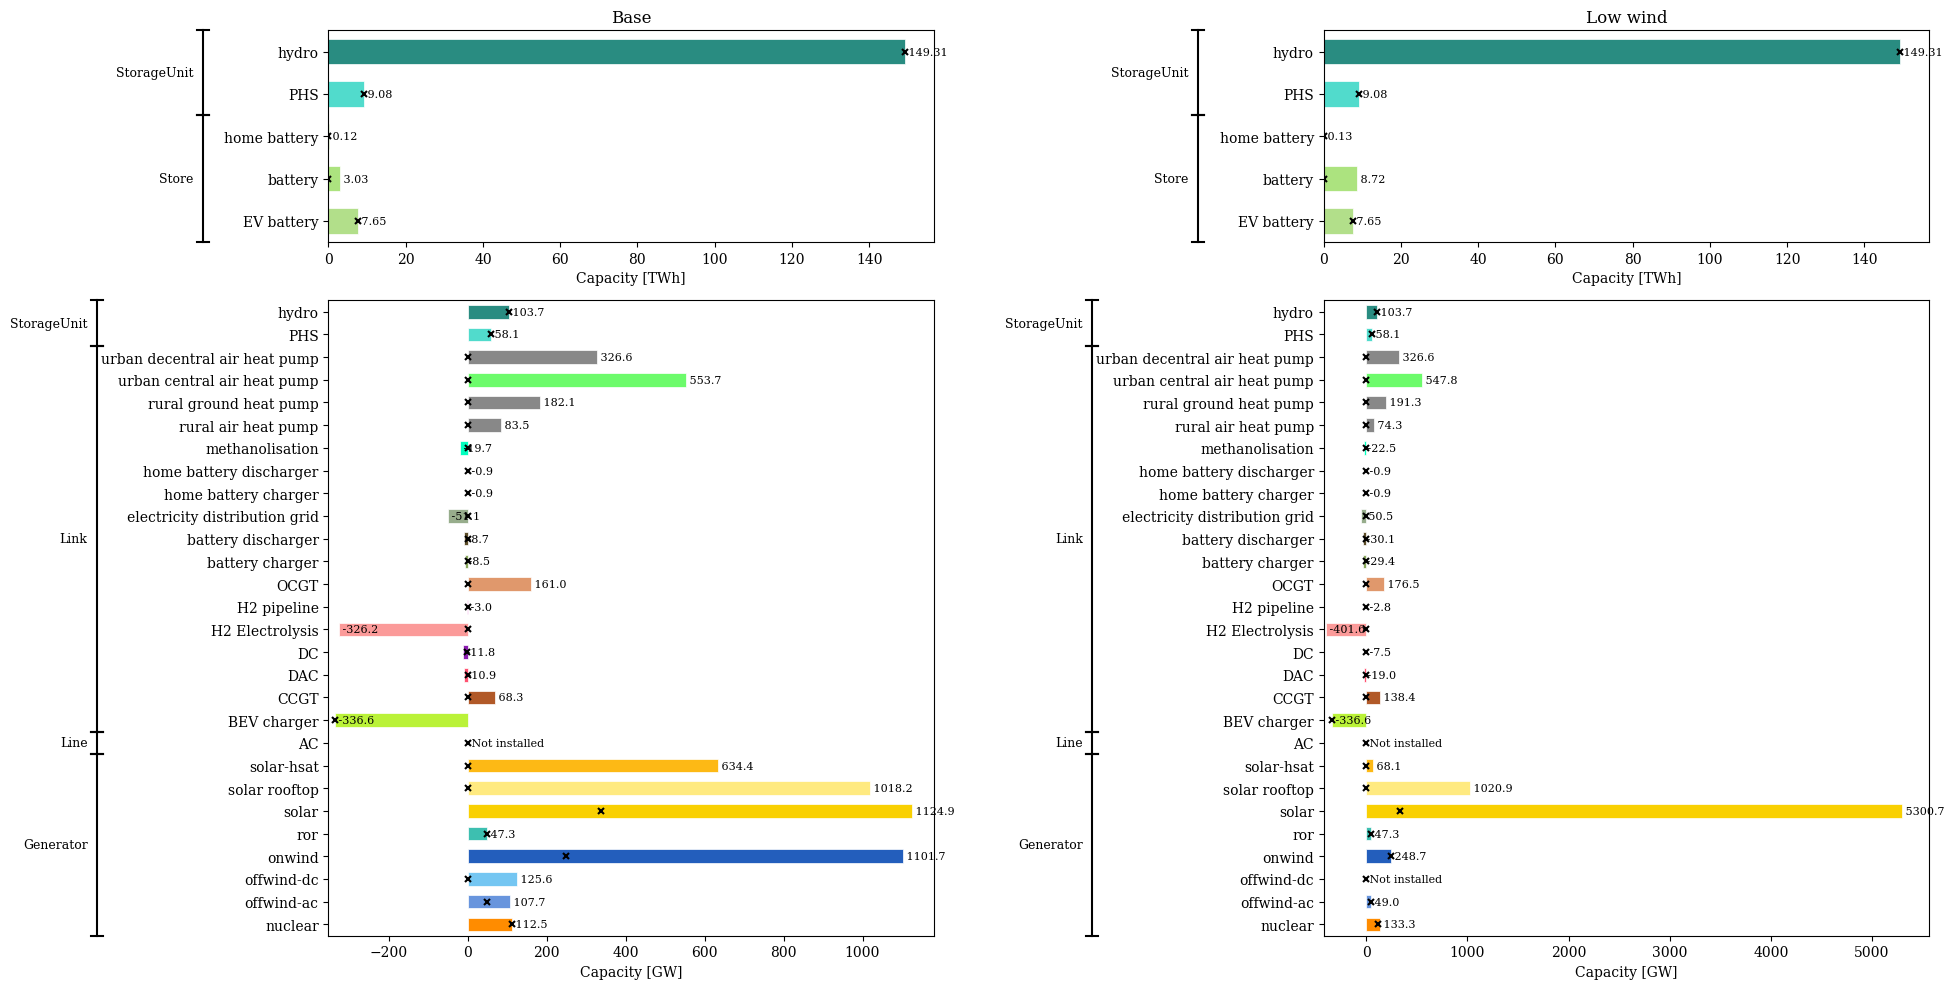

In [54]:
runs = [ sample_base_2h_irena_phs, sample_low_wind]
elec_carriers = ['AC', 'DC', 'Battery Storage', 'home battery', 'low voltage', 'EV battery', 'Battery Storage', 'battery']

fig, ax = plt.subplots(2, len(runs), figsize=(10 * len(runs), 10), gridspec_kw={"height_ratios": [1, 3]})

capacity_data = {}

for i, run in enumerate(runs):
    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", storage=True, bus_carrier=elec_carriers)
    energy_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        energy_df / 1e6,  # TWh
        ax[0, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [TWh]",
        title=run,
        annotate_decimals=2,
        show_legend=False,
    )

    inst = stats[run].installed_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    opt = stats[run].optimal_capacity(drop_zero=False, nice_names=False, round=3, groupby="carrier", bus_carrier=elec_carriers).drop("Store")
    power_df = pd.DataFrame({"Installed Capacity": inst, "Optimal Capacity": opt})

    plot_comparison_barh(
        power_df / 1e3,  # GW
        ax[1, i],
        lower_col="Installed Capacity",
        upper_col="Optimal Capacity",
        tech_colors=tech_colors,
        xlabel="Capacity [GW]",
        show_legend=False,
    )

plt.tight_layout()
plt.show()

### Elec generation by scenario

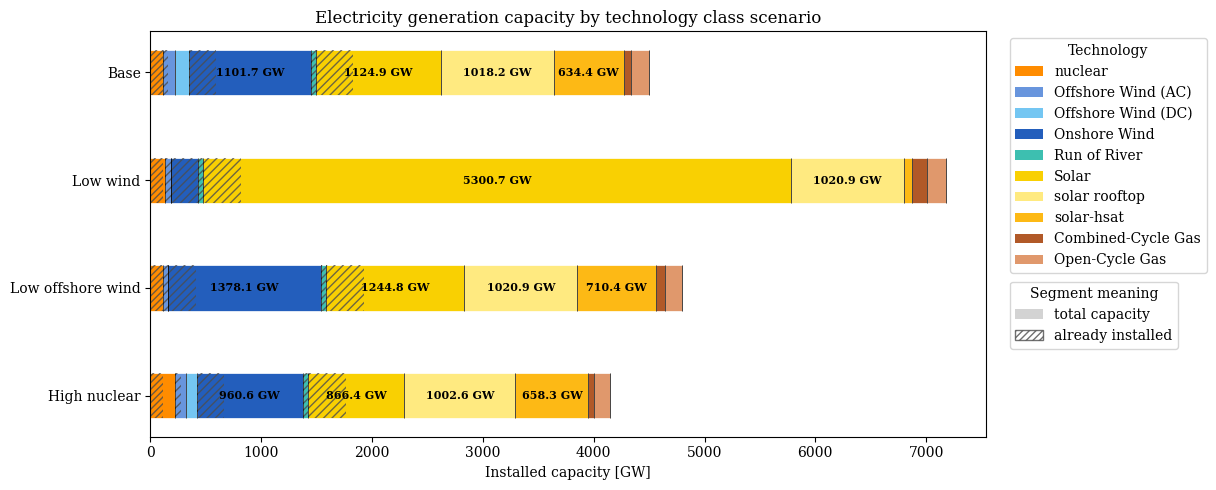

In [55]:
# Example usage
# runs = [sample_base_2h_irena_phs, sample_high_nuclear, sample_low_wind, sample_low_offwind]
runs = [sample_high_nuclear, sample_low_offwind, sample_low_wind, sample_base_2h_irena_phs]
elec_carriers = [
    "AC", "DC", "Battery Storage", "home battery", "low voltage", "EV battery", "battery"
]

cap_bounds = build_capacity_bounds_df(
    stats,
    runs,
    storage=False,
    bus_carrier=elec_carriers,
    scale=1e3,  # MW -> GW
)

fig, ax = plt.subplots(figsize=(12, 5))
plot_stacked_capacity(
    cap_bounds,
    ax,
    scenarios=runs,
    tech_colors=tech_colors,
    nice_names=nice_names,
    generation_only=True,
    p_nom_col="p_nom",
    p_nom_min_col="p_nom_min",
    title="Electricity generation capacity by technology class scenario"
)
fig.tight_layout()
plt.show()

### Storage by scenario

Index(['store', 'store', 'store', 'storageunit', 'storageunit'], dtype='object', name='component')


/var/folders/q9/5t5dtq65121dv3jhymly158h0000gn/T/ipykernel_28588/4018163740.py:51: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.



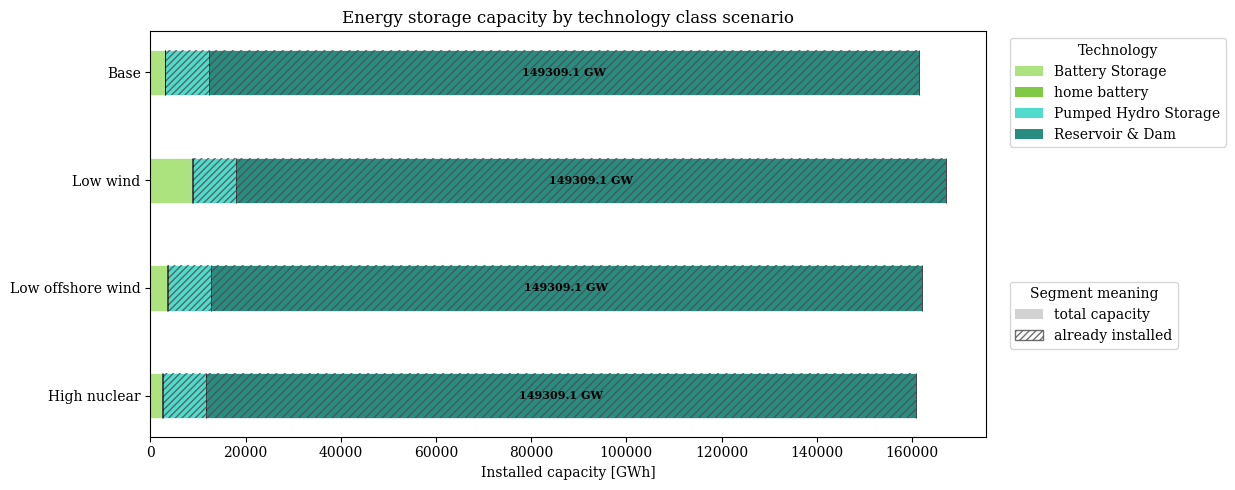

In [56]:
cap_bounds = build_capacity_bounds_df(
    stats,
    runs,
    storage=True,
    bus_carrier=elec_carriers,
    scale=1e3,  # MW -> GW
)

fig, ax = plt.subplots(figsize=(12, 5))
plot_stacked_capacity(
    cap_bounds,
    ax,
    scenarios=runs,
    tech_colors=tech_colors,
    nice_names=nice_names,
    storage_only=True,
    p_nom_col="p_nom",
    p_nom_min_col="p_nom_min",
    title="Energy storage capacity by technology class scenario"
)
fig.tight_layout()
plt.show()

## Yearly energy generation

In [57]:
def rename_techs_balances(tech):
    tech = rename_techs(tech)
    if "heat pump" in tech:
        return "ambient heat"
    elif tech in ["H2 Electrolysis"]:  # , "H2 liquefaction"]:
        return "power-to-hydrogen"
    elif "solar" in tech:
        return "solar"
    elif tech in ["Fischer-Tropsch", "methanolisation"]:
        return "power-to-liquid"
    elif tech == "DAC":
        return "direct air capture"
    elif "offshore wind" in tech:
        return "offshore wind"
    elif tech == "oil" or tech == "gas":
        return "fossil oil and gas"
    elif tech in ["BEV charger", "V2G", "Li ion", "land transport EV"]:
        return "battery electric vehicles"
    elif tech in ["biogas", "solid biomass"]:
        return "biomass"
    elif tech in ["electricity"]:
        return "residential electricity demand"
    elif tech in ["industry electricity", "agriculture electricity"]:
        return "industry electricity demand"
    elif tech in ["agriculture heat", "heat", "low-temperature heat for industry"]:
        return "heat demand"
    elif "solid biomass for industry" in tech:
        return "biomass demand"
    elif "gas for industry" in tech:
        return "methane demand"
    elif tech in ["H2 for industry", "land transport fuel cell"]:
        return "hydrogen demand"
    elif tech in [
        "kerosene for aviation",
        "naphtha for industry",
        "shipping methanol",
        "agriculture machinery oil",
    ]:
        return "liquid hydrocarbon demand"
    elif tech in [
        "transmission lines",
        "H2 pipeline",
        "H2 pipeline retrofitted",
        "H2",
        "electricity distribution grid",
        "SMR",
        "SMR CC",
        "OCGT",
        "CHP",
        "gas boiler",
        "H2 Fuel Cell",
        "resistive heater",
        "battery storage",
        "methanation",
    ]:
        return "other"
    else:
        return tech

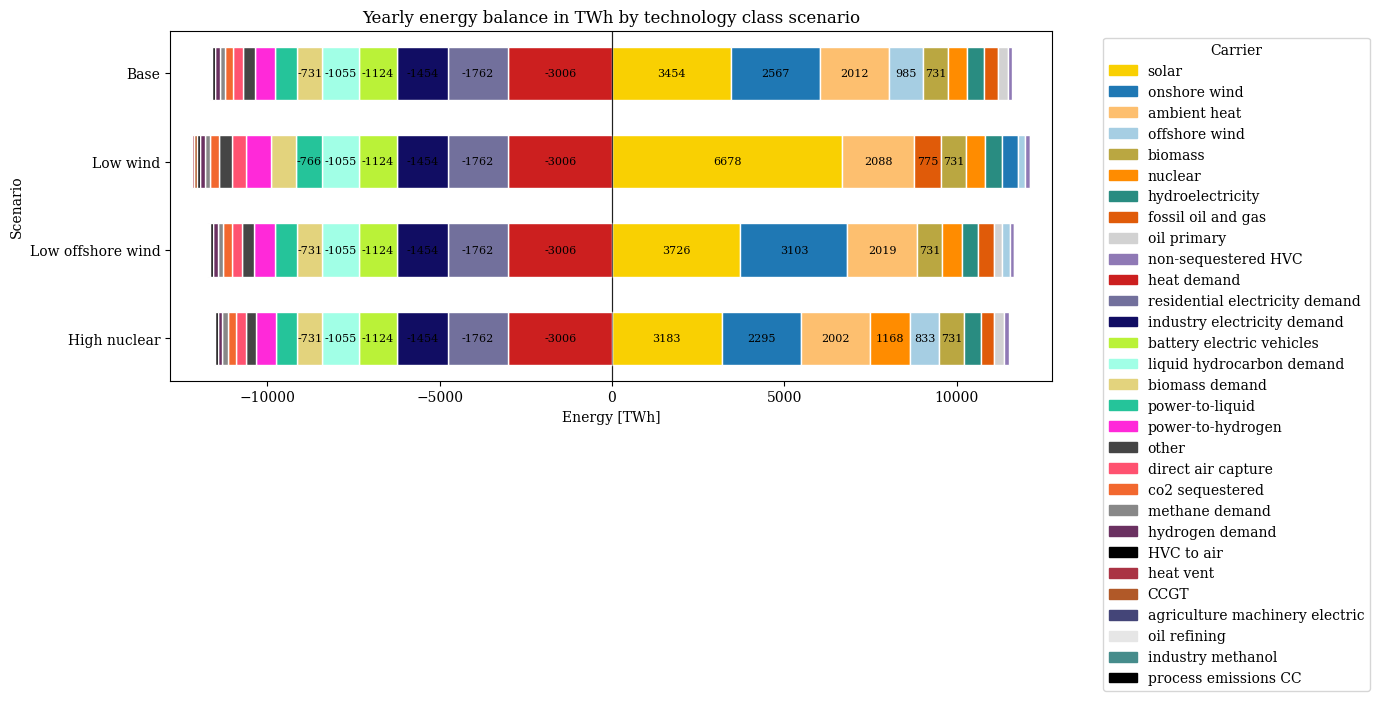

In [58]:
runs = [
    sample_base_2h_irena_phs,
    sample_low_wind,
    sample_low_offwind,
    sample_high_nuclear
]

series_by_run = {}
carriers_to_exclude = ["co2", "co2 stored", "process emissions"]

for run in runs:
    eb = stats[run].energy_balance(drop_zero=False, nice_names=False, round=3)
    eb_filtered = eb[~eb.index.get_level_values(1).isin(carriers_to_exclude)].groupby(["component", "carrier"]).sum()
    comp = eb_filtered.index.get_level_values(0)
    carrier_renamed = eb_filtered.index.get_level_values(1).map(rename_techs_balances)
    eb_tyndp = eb_filtered.groupby([ carrier_renamed]).sum()
    # eb_tyndp.index = eb_tyndp.index.set_names(eb_filtered.index.names)
    series_by_run[run] = eb_tyndp / 1e6  # TWh

# rows=scenarios, columns=(component, carrier)
plot_df = pd.DataFrame(series_by_run).T.fillna(0.0)

fig, ax = plt.subplots(figsize=(14, 1 * len(plot_df) + 2))
stacked_barh_signed(
    plot_df,
    ax,
    tech_colors=tech_colors,
    annotate_thresh=0.06,
    annotate_decimals=0,
)
ax.set_xlabel("Energy [TWh]")
plt.title("Yearly energy balance in TWh by technology class scenario")
plt.tight_layout()
plt.show()

## Mineral use

Compare overall mineral usage

### Mineral flow sankeys

In [61]:

network_key = sample_base_2h_irena_phs
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    all_minerals,
    tech_col="carrier_renamed",
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3,
    min_tech_share=0.05, 
    title = "a) Cumulative metal to technology flows in the base scenario"
)

In [62]:
network_key = sample_base_2h_irena_phs

df_merged, totals_Mt = compute_mineral_usage(network_key, n, rare_earths, "Market share current", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    rare_earths,
    tech_col="carrier_renamed",
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3,
    min_tech_share=0.05, 
    title = "b) Cumulative rare earth to technology flows in the base scenario"
)

In [63]:
network_key = sample_low_wind
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    [ 'Indium', 'Gallium'],
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3,
    min_tech_share=0.05
)

In [67]:
network_key = sample_low_wind
df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)

# assuming `criticality` DataFrame exists and includes
# "GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]" and a mineral name column
plot_mineral_to_tech_sankey(
    df_merged,
    all_minerals,
    tech_col=None,
    network_name=network_key,
    mode='mass',
    # criticality_df=criticality,
    criticality_min_col=None,   # or the actual mineral name column in your `criticality` DF
    criticality_score_col="GeoPolRisk Characterization Factor [eq. Kg-Cu/Kg]",
    fmt_decimals=3
)

To do: 
- Try criticality scores with different countries to validate scores. 


- Note: for supply comparison, we are comparing *yearly* supply (from IEA) to total cumulative demand from energy system until 2050

### Mineral use vs reserves

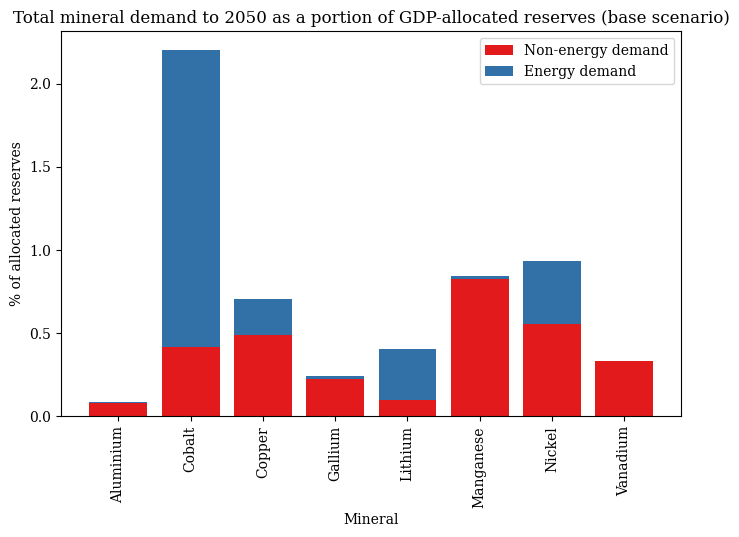

In [68]:
# now compare total demand to reserves
network_key = sample_base_2h_irena_phs

df_merged, totals_Mt = compute_mineral_usage(network_key, n, all_minerals, "Market share current", mineral_intensities, tech_scenarios)
totals_Mt.loc['REE'] = totals_Mt.loc[['Praseodymium', 'Neodymium', 'Dysprosium']].sum()
demand_df = totals_Mt.reset_index()
demand_df.columns = ['Mineral', 'Demand (Mt)']

non_energy_demand_cumulative = non_energy_demand[non_energy_demand["Year"] == "Cumulative"][["Mineral", "GDP-adjusted value entso-e (Mt)"]]


reserves = mineral_avail[mineral_avail['Estimate method']=="Reserves"]

# Merge reserves with energy demand and non-energy demand
merged = pd.merge(reserves,
                  demand_df,
                  on='Mineral',
                  how='outer') 
merged = pd.merge(merged,
                  non_energy_demand_cumulative, 
                  on="Mineral", 
                  how="inner")


merged.rename(columns={"GDP-adjusted value entso-e (Mt)":"Non-energy demand (Mt)"}, inplace=True)
merged["GDP-allocated reserves"] =merged["Value (Mt)"] * mineral_alloc_factors["GDP share"]

merged["Eur transition demand per total reserves"] = merged["Demand (Mt)"]/merged["Value (Mt)"]
merged["Eur transition demand per total allocated reserves"] = merged["Demand (Mt)"]/merged["GDP-allocated reserves"]

merged["Eur other demand per total reserves"] = merged["Non-energy demand (Mt)"]/merged["Value (Mt)"]
merged["Eur other demand per total allocated reserves"] = merged["Non-energy demand (Mt)"]/merged["GDP-allocated reserves"]

fig, ax = plt.subplots(figsize=(8, 5))

to_plot = merged[(~merged["Value (Mt)"].isna()) & (~merged["Demand (Mt)"].isna())]
# to_plot

ax.bar(to_plot["Mineral"], to_plot["Eur other demand per total allocated reserves"], color="#e31a1c", label="Non-energy demand")
ax.bar(to_plot["Mineral"], to_plot["Eur transition demand per total allocated reserves"], bottom=to_plot["Eur other demand per total allocated reserves"], color="#3271a8", label="Energy demand")

ax.set_ylabel("% of allocated reserves")
ax.set_xlabel("Mineral")

plt.xticks(rotation=90)
plt.title("Total mineral demand to 2050 as a portion of GDP-allocated reserves (base scenario)")
plt.legend(loc="upper right")

plt.show()

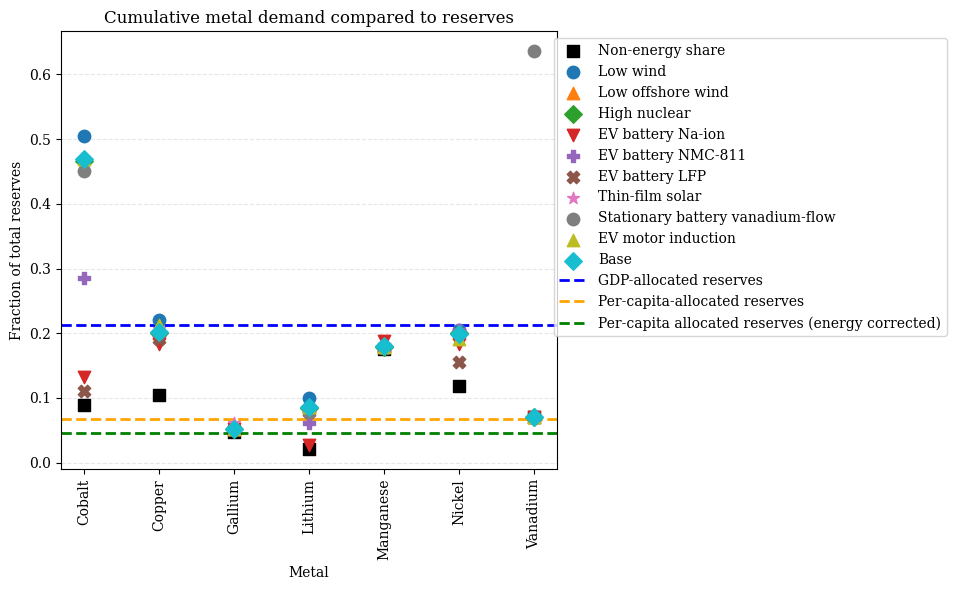

In [69]:
def plot_mineral_reserve_shares(
    scenario_defs,
    n,
    minerals,
    mineral_intensities,
    tech_scenarios,
    non_energy_demand,
    grid_demand,
    mineral_avail,
    mineral_alloc_factors,
    reserve_method="Reserves",
    reserve_allocation_key="GDP share",
    non_energy_year="Cumulative",
    non_energy_col="GDP-adjusted value entso-e (Mt)",
    figsize=(15, 6),
    marker_map=None,
    color_map=None,
    title=None,
):
    """Plot non-energy + energy mineral demand as a share of reserves across scenarios."""
    
    # --- Base data ---
    reserves = mineral_avail[mineral_avail["Estimate method"] == reserve_method].copy()
    reserves = reserves[reserves["Mineral"].isin(minerals)].copy()

    non_energy = (
        non_energy_demand[non_energy_demand["Year"] == non_energy_year]
        [["Mineral", non_energy_col]]
        .rename(columns={non_energy_col: "Non-energy (Mt)"})
    )

    merged = pd.merge(reserves, non_energy, on="Mineral", how="inner")
    # merged["Allocated reserves (Mt)"] = (
    #     merged["Value (Mt)"] * mineral_alloc_factors[reserve_allocation_key]
    # )
    merged["Non-energy share"] = merged["Non-energy (Mt)"] / merged["Value (Mt)"]
    
    # Optional cumulative grid demand term (expected to be non-zero for Copper)
    grid_extra_Mt = pd.Series(0.0, index=merged["Mineral"])
    if (
        grid_demand is not None
        and not grid_demand.empty
        and {"Mineral", "Year", "GDP-adjusted value entso-e (Mt)"}.issubset(grid_demand.columns)
    ):
        grid_cumulative = grid_demand[grid_demand["Year"] == "Cumulative"].copy()
        grid_extra_Mt = (
            grid_cumulative.groupby("Mineral")["GDP-adjusted value entso-e (Mt)"]
            .sum()
            .reindex(merged["Mineral"])
            .fillna(0.0)
        )

    if merged["Value (Mt)"].isna().any():
        raise ValueError("Some minerals have missing allocated reserves. Check reserve_method/alloc factor.")

    # Compute energy demand for each scenario and stack on top of non-energy
    results = []
    for label, network_key, scenario in scenario_defs:
        _, totals_Mt = compute_mineral_usage(
            network_key,
            n,
            all_minerals,
            scenario,
            mineral_intensities,
            tech_scenarios,
        )

        totals_Mt.loc["REE"] = totals_Mt.loc[["Praseodymium", "Neodymium", "Dysprosium"]].sum()

        totals_Mt = totals_Mt.reindex(merged["Mineral"]).fillna(0)
        merged[f"Energy (Mt) - {label}"] = totals_Mt.values

        # Add cumulative grid demand before normalizing by reserves
        merged[f"Energy share - {label}"] = (
            merged[f"Energy (Mt) - {label}"] + grid_extra_Mt.values
        ) / merged["Value (Mt)"]

        merged[f"Total share - {label}"] = merged["Non-energy share"] + merged[f"Energy share - {label}"]
        results.append(label)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)
    minerals_order = [m for m in minerals if m in merged["Mineral"].values]
    x = np.arange(len(minerals_order))
    merged = merged.set_index("Mineral").reindex(minerals_order).reset_index()

    # # Plot non-energy baseline as a square marker
    ax.scatter(
        x,
        merged["Non-energy share"],
        marker="s",
        s=80,
        color="black",
        label="Non-energy share",
        zorder=3,
    )

    # Plot each scenario on top
    if marker_map is None:
        base_markers = ["o", "^", "D", "v", "P", "X", "*"]
        marker_map = {label: base_markers[i % len(base_markers)] for i, label in enumerate(results)}
    if color_map is None:
        cmap = plt.get_cmap("tab10")
        color_map = {label: cmap(i) for i, label in enumerate(results)}

    for label in results:
        ys = merged[f"Total share - {label}"]
        ax.scatter(
            x,
            ys,
            marker=marker_map[label],
            s=80,
            color=color_map[label],
            label=label,
            zorder=4,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(minerals_order, rotation=90)
    ax.set_ylabel("Fraction of total reserves")
    ax.set_xlabel("Metal")
    ax.set_title(title or "Mineral demand (non-energy + energy) as share of GDP-allocated reserves")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    # add lines for gdp, per capita, and per capita adjusted for energy
    

    ax.axhline(y=mineral_alloc_factors['GDP share'], color='blue', linestyle='--', linewidth=2, label='GDP-allocated reserves', zorder=2)
    ax.axhline(y=mineral_alloc_factors['Per capita share'], color='orange', linestyle='--', linewidth=2, label='Per-capita-allocated reserves', zorder=2)
    ax.axhline(y=mineral_alloc_factors['Per capita share corrected for energy use'], color='green', linestyle='--', linewidth=2, label='Per-capita allocated reserves (energy corrected)', zorder=2)

    ax.legend(loc="upper right", bbox_to_anchor=(1.8, 1))
    plt.tight_layout()

    return merged


# Example usage (matches the stacked bar chart example above):
# Guarded so this cell can be run even if the example scenarios are not defined yet.

scenario_defs = [
    (sample_low_wind, sample_low_wind, "Market share current"),
    (sample_low_offwind, sample_low_offwind, "Market share current"),
    (sample_high_nuclear, sample_high_nuclear, "Market share current"),
    ("EV battery Na-ion", sample_base_2h_irena_phs, "EV battery Na-ion"),
    ("EV battery NMC-811", sample_base_2h_irena_phs, "EV battery NMC-811"),
    ("EV battery LFP", sample_base_2h_irena_phs, "EV battery LFP"),
    ("Thin-film solar", sample_base_2h_irena_phs, "Thin-film solar"),
    ("Stationary battery vanadium-flow", sample_base_2h_irena_phs, "Stationary battery vanadium-flow"),
    ("EV motor induction", sample_base_2h_irena_phs, "EV motor induction"),
    (sample_base_2h_irena_phs, sample_base_2h_irena_phs, "Market share current"),
]


battery_minerals = ["Cobalt", "Copper", "Gallium", "Graphite", "Lithium", "Manganese", "Nickel", "Vanadium"]
# battery_minerals = ["Lithium", "Graphite","Cobalt", "Manganese", "Nickel",  "Vanadium", "Gallium", "Neodymium", "Dysprosium", "Tellurium", "REE"]

test = plot_mineral_reserve_shares(
    scenario_defs,
    n,
    battery_minerals,
    mineral_intensities,
    tech_scenarios,
    non_energy_demand,
    grid_demand,
    mineral_avail,
    mineral_alloc_factors,
    title="Cumulative metal demand compared to reserves",
)

test.to_csv("reserves_plot_data.csv")




###  Mineral Supply

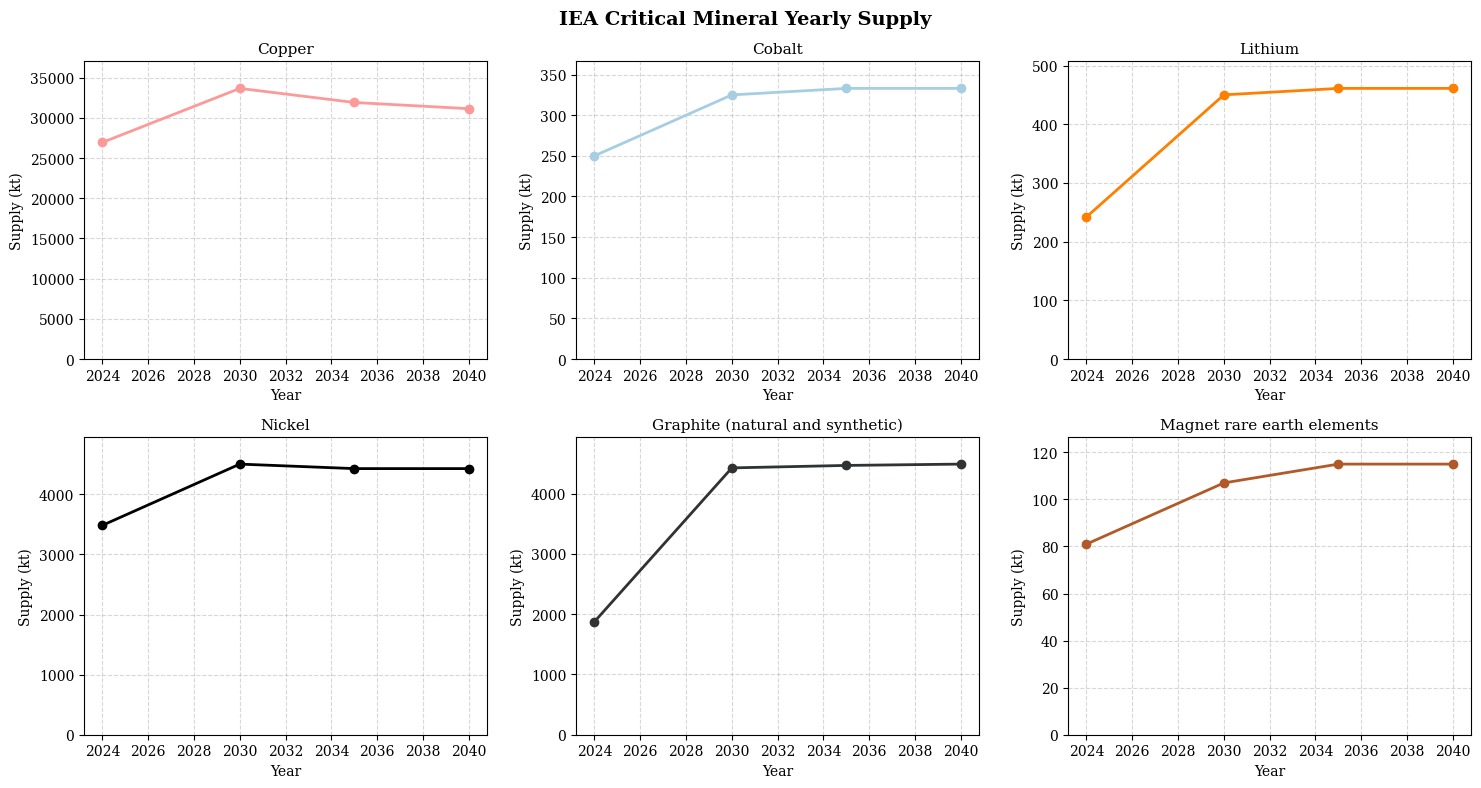

In [70]:
iea_supply_yearly = pd.read_csv("data/IEA_cm_yearly_avail.csv")
extrapolated_supply_yearly = pd.read_csv("data/extrapolated supply.csv")

iea_supply_yearly.columns = iea_supply_yearly.columns.str.strip()
minerals_in_df = [c for c in iea_supply_yearly.columns if c != "Year" and not c.startswith("Unnamed")]

# Fallback overrides for column names that may differ from minerals_color_map keys
_color_overrides = {
    "Magnet rare earth elements": minerals_color_map.get("Magnet rare earth elements", minerals_color_map.get("REE", "#b15928")),
    "Graphite": minerals_color_map.get("Graphite", minerals_color_map.get("Graphite (natural and synthetic)", "#303234")),
}

def _get_color(mineral):
    return minerals_color_map.get(mineral) or _color_overrides.get(mineral, "#888888")

n_minerals = len(minerals_in_df)
ncols = 3
nrows = (n_minerals + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

# years_with_data=[2024, 2030, 2035, 2040]

for i, mineral in enumerate(minerals_in_df):
    ax = axes[i]
    ax.plot(iea_supply_yearly["Year"], iea_supply_yearly[mineral], color=_get_color(mineral), linewidth=2, marker="o")
    ax.set_title(mineral, fontsize=11)
    ax.set_xlabel("Year")
    ax.set_ylabel("Supply (kt)")
    # ax.set_xticks(years_with_data)
    ax.set_ylim(bottom=0, top=iea_supply_yearly[mineral].max() * 1.1)
    ax.grid(True, linestyle="--", alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("IEA Critical Mineral Yearly Supply", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

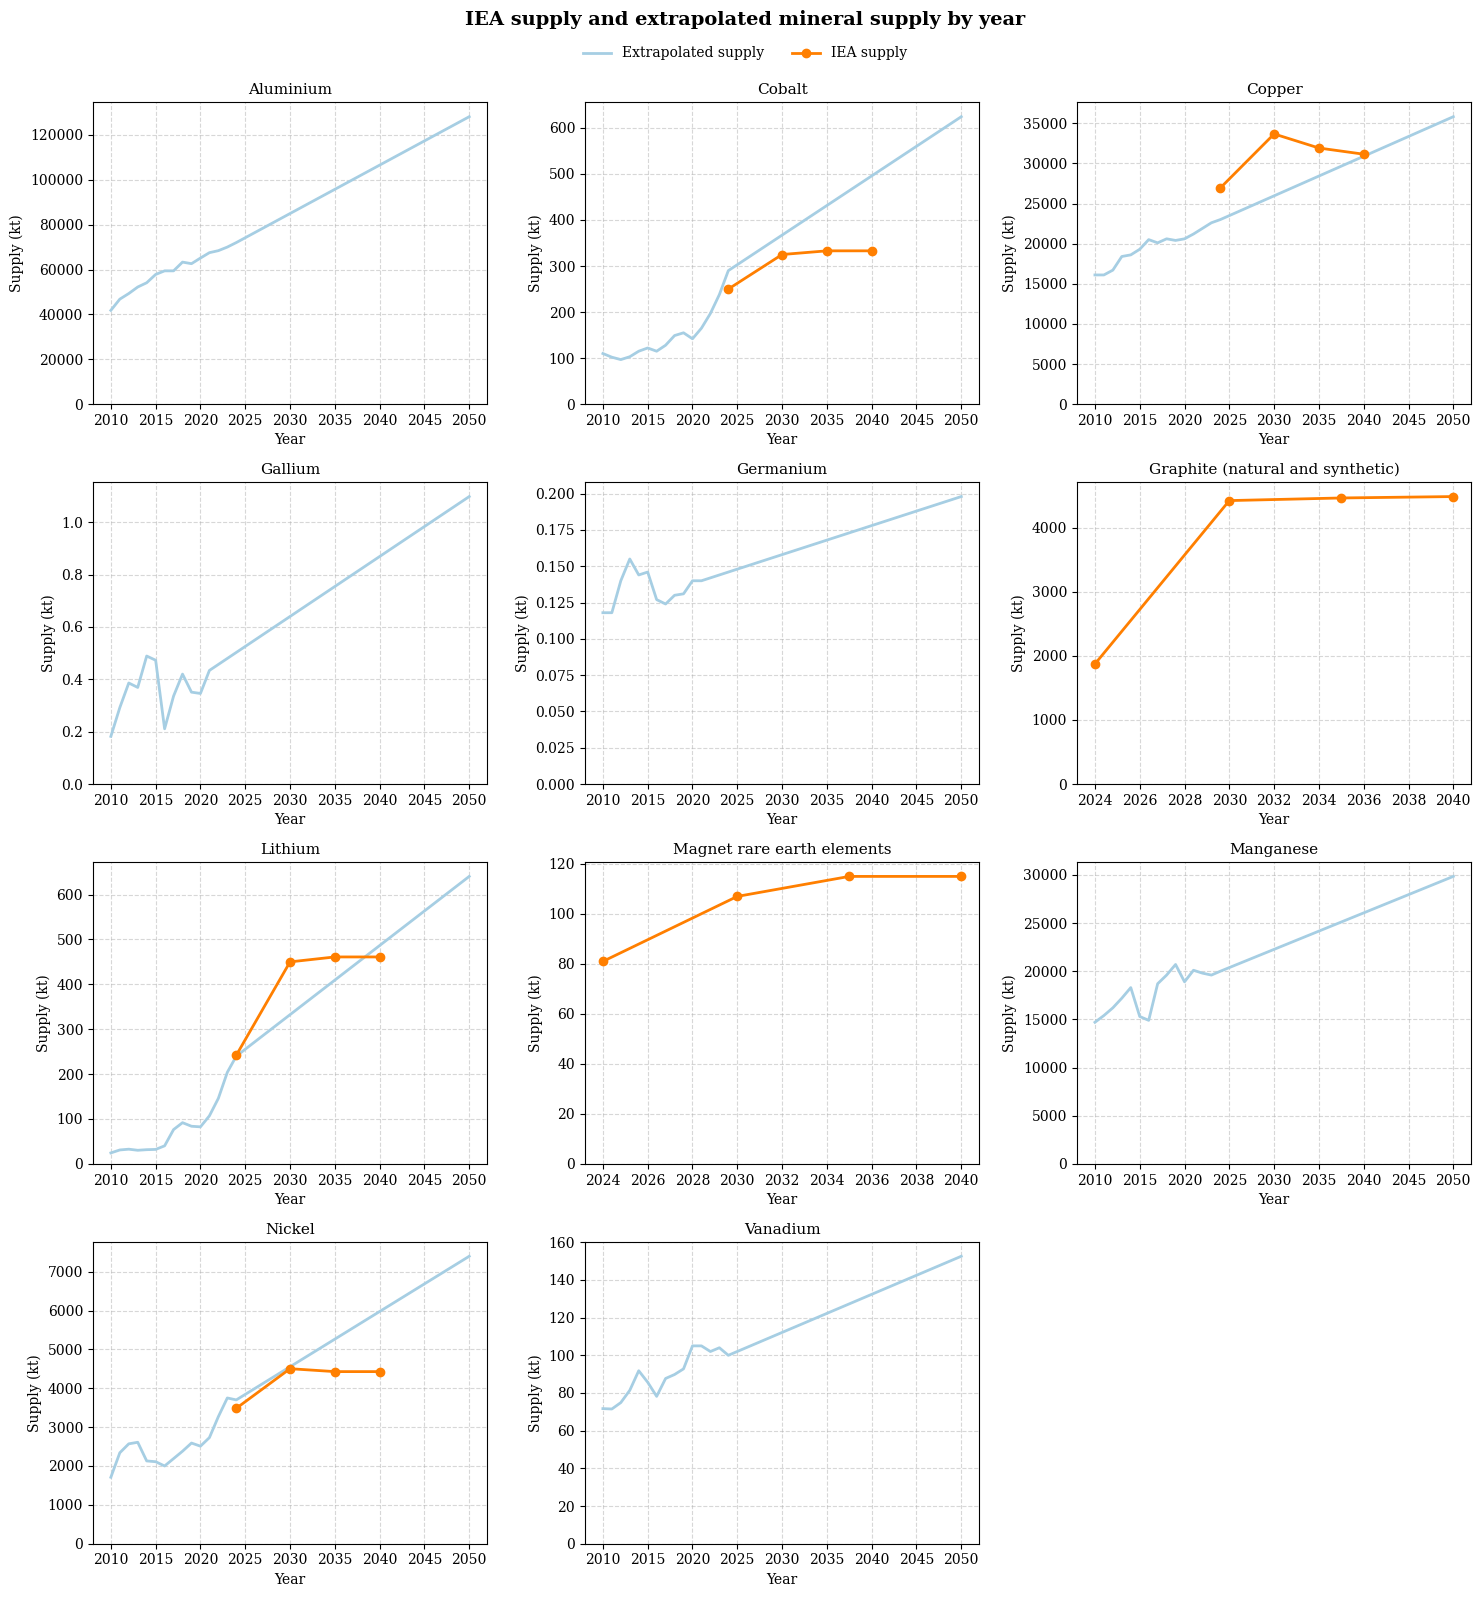

In [71]:
extrapolated_supply_yearly = pd.read_csv("data/extrapolated supply.csv")
iea_supply_yearly = pd.read_csv("data/IEA_cm_yearly_avail.csv")

minerals_in_df = sorted(
    c for c in set(extrapolated_supply_yearly.columns) | set(iea_supply_yearly.columns)
    if c != "Year" and not c.startswith("Unnamed")
)

def _get_color(mineral):
    return minerals_color_map.get(mineral) or _color_overrides.get(mineral, "#888888")

n_minerals = len(minerals_in_df)
ncols = 3
nrows = (n_minerals + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

# years_with_data=[2024, 2030, 2035, 2040]

for i, mineral in enumerate(minerals_in_df):
    ax = axes[i]
    y_max_candidates = []

    if mineral in extrapolated_supply_yearly.columns:
        y1 = extrapolated_supply_yearly[mineral]
        ax.plot(extrapolated_supply_yearly["Year"], y1, color="#a6cee3", linewidth=2)
        y_max_candidates.append(y1.max())

    if mineral in iea_supply_yearly.columns:
        y2 = iea_supply_yearly[mineral]
        ax.plot(iea_supply_yearly["Year"], y2, color="#ff7f00", linewidth=2, marker="o")
        y_max_candidates.append(y2.max())

    # y-axis from 0 to (max plotted value + 5%)
    if y_max_candidates:
        y_max = max(y_max_candidates)
        ax.set_ylim(0, y_max * 1.05)
    
    ax.set_title(mineral, fontsize=11)
    ax.set_xlabel("Year")
    ax.set_ylabel("Supply (kt)")
    ax.set_ylim(bottom=0)
    # ax.set_xticks(years_with_data)
    # ax.set_ylim(bottom=0, top=extrapolated_supply_yearly[mineral].max() * 1.1)
    ax.grid(True, linestyle="--", alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

legend_handles = [
    Line2D([0], [0], color="#a6cee3", lw=2, label="Extrapolated supply"),
    Line2D([0], [0], color="#ff7f00", lw=2, marker="o", label="IEA supply"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.980)
)

fig.suptitle(
    "IEA supply and extrapolated mineral supply by year",
    fontsize=14,
    fontweight="bold",
    y=0.995
)
# Reserve top for suptitle and bottom for legend
plt.tight_layout(rect=[0, 0, 1, 0.98])

### Cumulative mineral use (main chart)

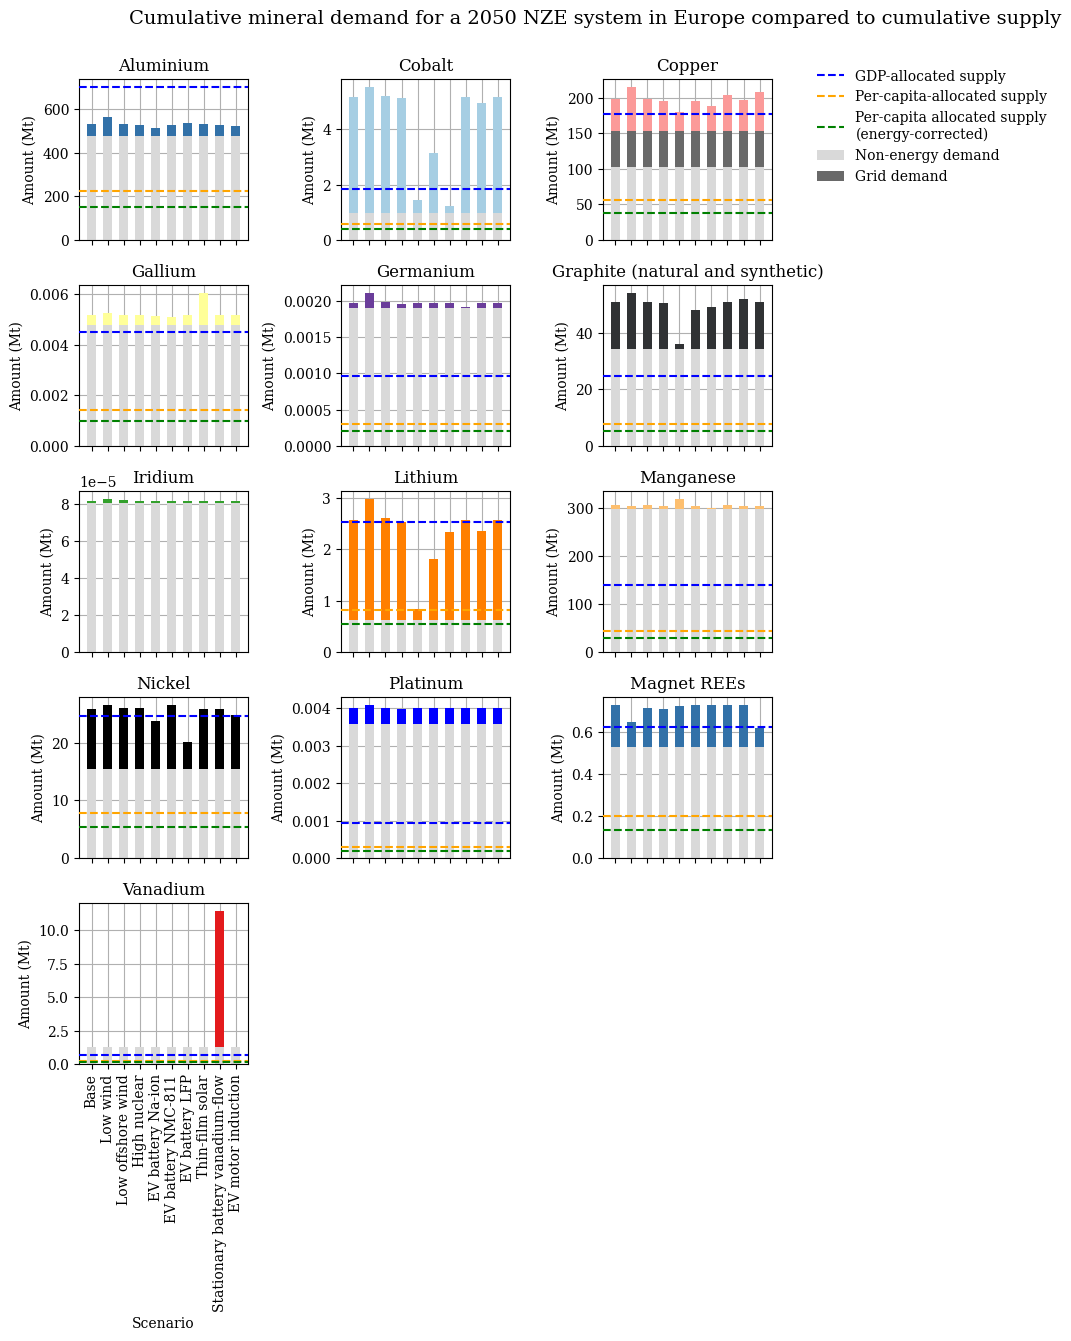

In [72]:
# Example: one figure with minerals drawing from different non-energy and availability datasets
base_scenario = sample_base_2h_irena_phs
network_scenarios = [sample_base_2h_irena_phs, sample_low_wind, sample_low_offwind, sample_high_nuclear]
market_scenarios = [
    "EV battery Na-ion",
    "EV battery NMC-811",
    "EV battery LFP",
    "Thin-film solar",
    "Stationary battery vanadium-flow",
    "EV motor induction"
]

mineral_specs = [
    {
        "mineral": "Aluminium",
        "DNEA_source": "Bieuville et at. (SSP2), which used (Pedneault et al., 2022)",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
    {
        "mineral": "Cobalt",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    {
        "mineral": "Copper",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": "Cumulative"
    },
    {
        "mineral": "Gallium",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
    {
        "mineral": "Germanium",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },

    {
        "mineral": "Graphite (natural and synthetic)",
        "energy_minerals": ["Graphite", "Graphite (synthetic)"],
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    {
        "mineral": "Iridium",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
    
    {
        "mineral": "Lithium",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    {
        "mineral": "Manganese",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
    
    {
        "mineral": "Nickel",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    {
        "mineral": "Platinum",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
    {
        "mineral": "Magnet REEs",
        "energy_minerals": rare_earths,
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    {
        "mineral": "Vanadium",
        "DNEA_source": "Schlichenmaier and Naegler 2022",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
]

mineral_scenario_comparison_mixed_sources(
    n,
    base_scenario,
    network_scenarios,
    market_scenarios,
    mineral_specs,
    fig_title = "Cumulative mineral demand for a 2050 NZE system in Europe compared to cumulative supply"
)

In [73]:
# cobalt overuse
print((4.19380179+0.97210767)/1.8346392399449998)

#nickel overuse: 
print((15.38434922+10.50035203)/24.617689704)

# graphite
print((34.22322248+16.49083768)/24.7623029016)

# manganese
print((298.48851851+6.70524296)/139.0631357082)

# vanadium
print((1.26726141)/0.704928064377)

# cobalt use from EVs
print(3.975521/(0.97210767+4.19380179))

# lithium use from EVs
print(1.748298/(0.61657894+1.96683515))


2.815763092560294
1.051467524419813
2.048034884377541
2.1946417353222674
1.797717347400515
0.7695684623942287
0.6767393608200069


Aluminium
DNEA: [478.15398379 478.15398379 478.15398379 478.15398379 478.15398379
 478.15398379 478.15398379 478.15398379 478.15398379 478.15398379]
Grid: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
carrier_renamed                   EV battery      Solar  EV motor  \
Base                               27.675494   4.617917  7.494094   
Low wind                           27.675494  29.096416  7.494094   
Low offshore wind                  27.675494   5.320863  7.494094   
High nuclear                       27.675494   3.102652  7.494094   
EV battery Na-ion                   8.928747   4.617917  7.494094   
EV battery NMC-811                 24.750248   4.617917  7.494094   
EV battery LFP                     32.104376   4.617917  7.494094   
Thin-film solar                    27.675494   4.726629  7.494094   
Stationary battery vanadium-flow   27.675494   4.617917  7.494094   
EV motor induction                 27.675494   4.617917  0.000000   

carrier_renamed                   solar rooftop  Batt

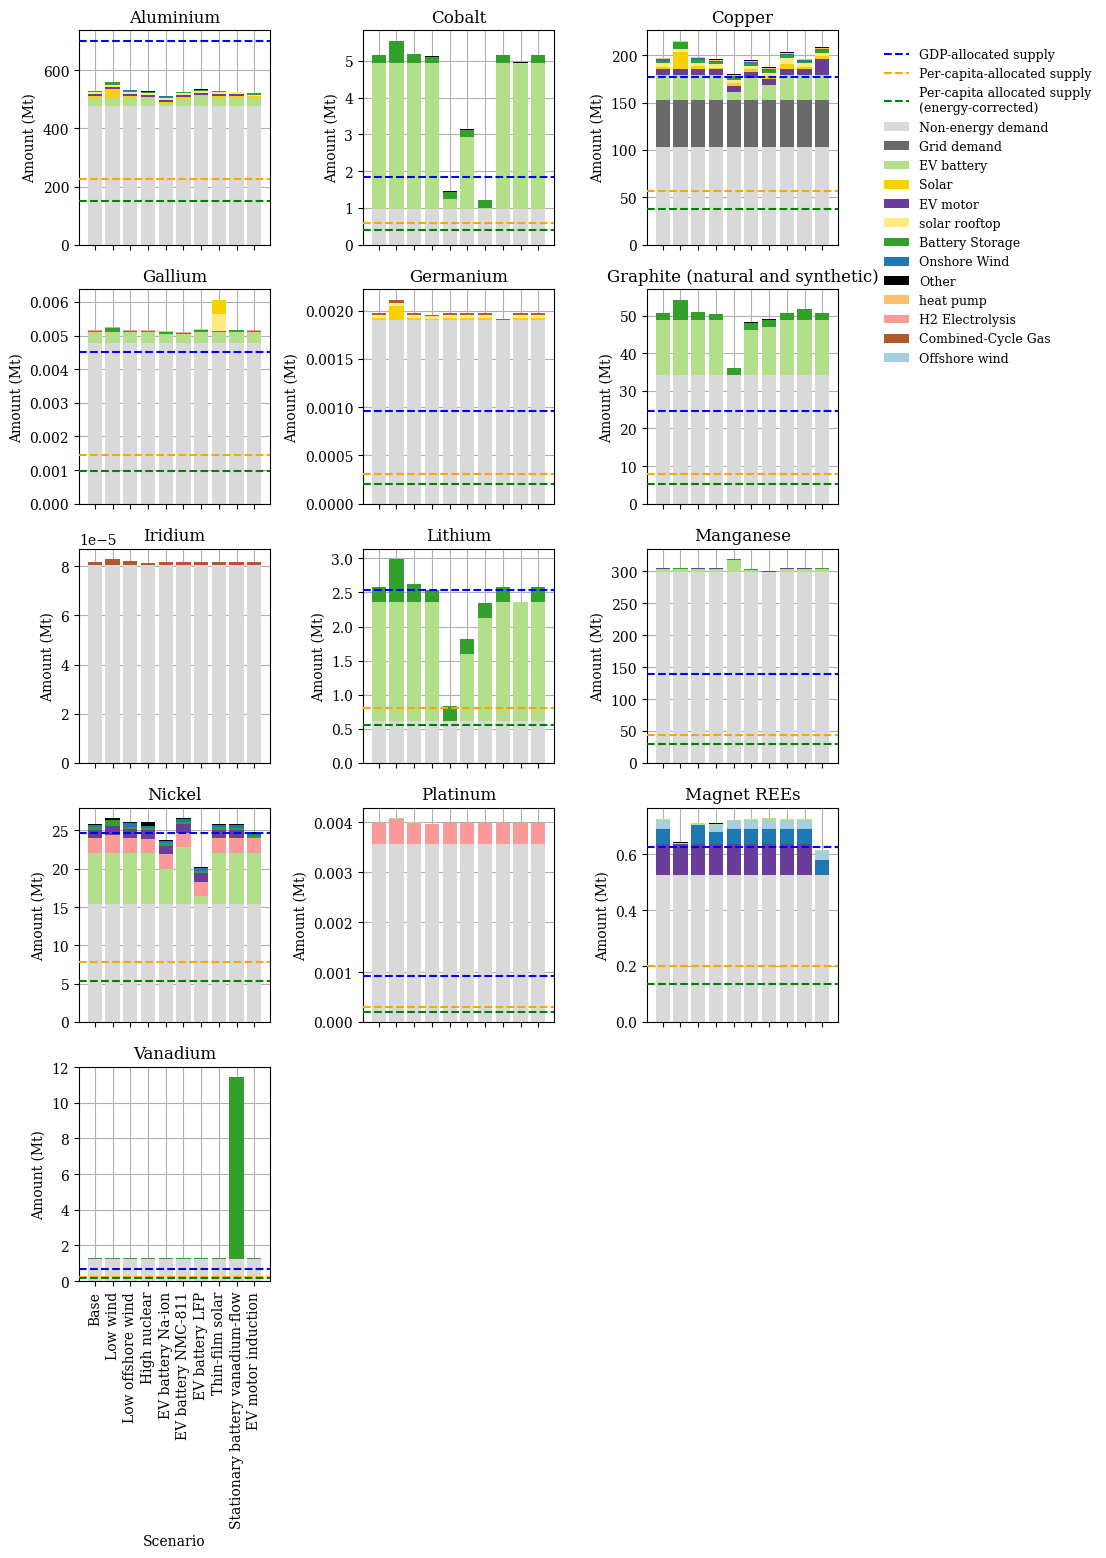

In [74]:
mineral_scenario_comparison_mixed_sources_by_technology(
    n,
    base_scenario,
    network_scenarios,
    market_scenarios,
    mineral_specs
)

Smaller versions of main chart for presentation: 

Cobalt
DNEA: [0.97210767 0.97210767 0.97210767 0.97210767 0.97210767 0.97210767
 0.97210767 0.97210767 0.97210767 0.97210767]
Grid: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
carrier_renamed                   EV battery  Battery Storage     Other
Base                                3.975521         0.206432  0.011849
Low wind                            3.975521         0.594147  0.013007
Low offshore wind                   3.975521         0.239282  0.011994
High nuclear                        3.975521         0.164662  0.012172
EV battery Na-ion                   0.265830         0.206432  0.011849
EV battery NMC-811                  1.944759         0.206432  0.011849
EV battery LFP                      0.027794         0.206432  0.011849
Thin-film solar                     3.975521         0.206432  0.011849
Stationary battery vanadium-flow    3.975521         0.003147  0.011849
EV motor induction                  3.975521         0.206432  0.005133
Energy demand: [4.19380179 4.58267502 4.2267

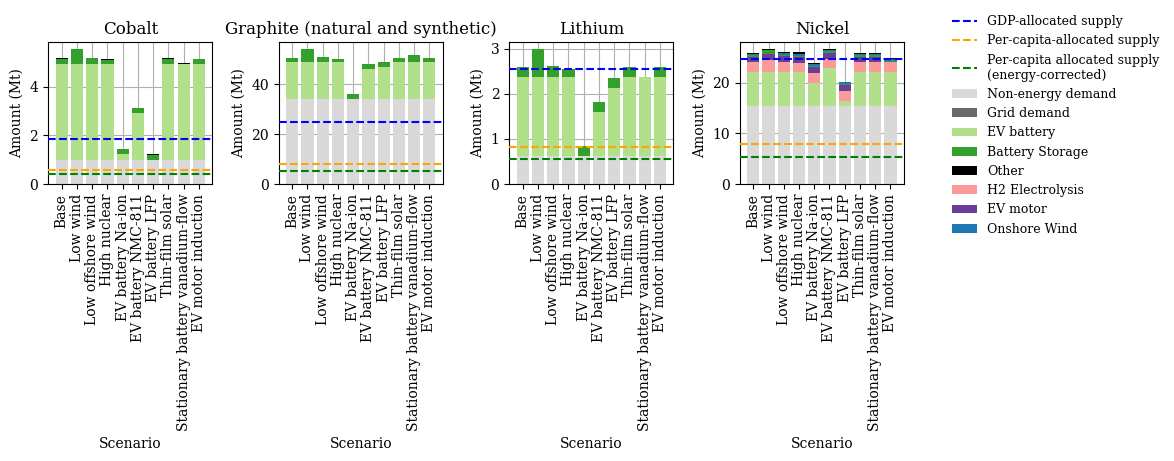

In [51]:
# Example: one figure with minerals drawing from different non-energy and availability datasets
base_scenario = sample_base_2h_irena_phs
network_scenarios = [sample_base_2h_irena_phs, sample_low_wind, sample_low_offwind, sample_high_nuclear]
market_scenarios = [
    "EV battery Na-ion",
    "EV battery NMC-811",
    "EV battery LFP",
    "Thin-film solar",
    "Stationary battery vanadium-flow",
    "EV motor induction"
]

mineral_specs = [
    {
        "mineral": "Cobalt",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },

    {
        "mineral": "Graphite (natural and synthetic)",
        "energy_minerals": ["Graphite", "Graphite (synthetic)"],
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    
    {
        "mineral": "Lithium",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    },
    
    {
        "mineral": "Nickel",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    }
]

mineral_scenario_comparison_mixed_sources_by_technology(
    n,
    base_scenario,
    network_scenarios,
    market_scenarios,
    mineral_specs,
    ncols = 4
)

Aluminium
DNEA: [478.15398379 478.15398379 478.15398379 478.15398379 478.15398379
 478.15398379 478.15398379 478.15398379 478.15398379 478.15398379]
Grid: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
carrier_renamed                   EV battery      Solar  EV motor  \
Base                               27.675494   4.617917  7.494094   
Low wind                           27.675494  29.096416  7.494094   
Low offshore wind                  27.675494   5.320863  7.494094   
High nuclear                       27.675494   3.102652  7.494094   
EV battery Na-ion                   8.928747   4.617917  7.494094   
EV battery NMC-811                 24.750248   4.617917  7.494094   
EV battery LFP                     32.104376   4.617917  7.494094   
Thin-film solar                    27.675494   4.726629  7.494094   
Stationary battery vanadium-flow   27.675494   4.617917  7.494094   
EV motor induction                 27.675494   4.617917  0.000000   

carrier_renamed                   solar rooftop  Batt

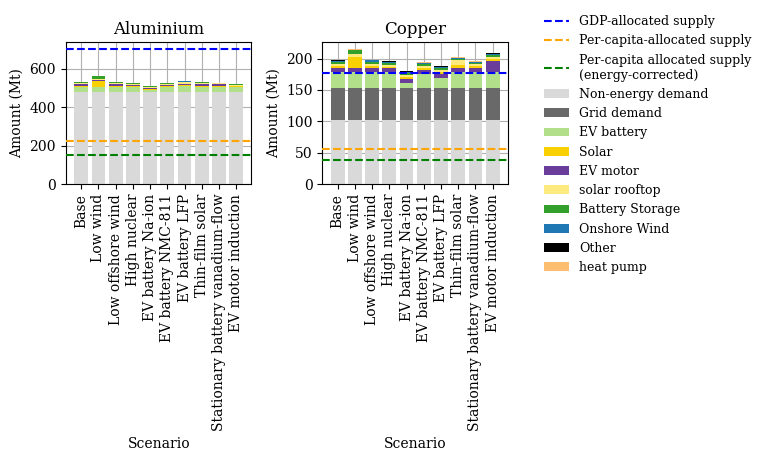

In [57]:
# Example: one figure with minerals drawing from different non-energy and availability datasets
base_scenario = sample_base_2h_irena_phs
network_scenarios = [sample_base_2h_irena_phs, sample_low_wind, sample_low_offwind, sample_high_nuclear]
market_scenarios = [
    "EV battery Na-ion",
    "EV battery NMC-811",
    "EV battery LFP",
    "Thin-film solar",
    "Stationary battery vanadium-flow",
    "EV motor induction"
]

mineral_specs = [
{
        "mineral": "Aluminium",
        "DNEA_source": "Bieuville et at. (SSP2), which used (Pedneault et al., 2022)",
        "DNEA_year": "Cumulative",
        "avail_source": "USGS (linear extrapolation)",
        "avail_year": "Cumulative",
        "avail_method": "Production",
        "grid_demand_year": ""
    },
    {
        "mineral": "Copper",
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": "Cumulative"
    },
]

mineral_scenario_comparison_mixed_sources_by_technology(
    n,
    base_scenario,
    network_scenarios,
    market_scenarios,
    mineral_specs,
    ncols = 2,
    figwidth = 8
)

Magnet REEs
DNEA: [0.52552353 0.52552353 0.52552353 0.52552353 0.52552353 0.52552353
 0.52552353 0.52552353 0.52552353 0.52552353]
Grid: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
carrier_renamed                   EV motor  Onshore Wind  Offshore wind  \
Base                              0.110011      0.052372       0.031296   
Low wind                          0.110011      0.000000       0.000000   
Low offshore wind                 0.110011      0.069341       0.000000   
High nuclear                      0.110011      0.043711       0.024207   
EV battery Na-ion                 0.110011      0.052372       0.031296   
EV battery NMC-811                0.110011      0.052372       0.031296   
EV battery LFP                    0.110011      0.052372       0.031296   
Thin-film solar                   0.110011      0.052372       0.031296   
Stationary battery vanadium-flow  0.110011      0.052372       0.031296   
EV motor induction                0.000000      0.052372       0.031296   

carri

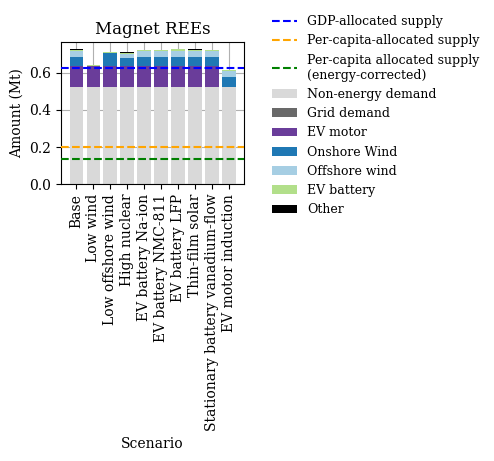

In [62]:
mineral_specs = [
{
        "mineral": "Magnet REEs",
        "energy_minerals": rare_earths,
        "DNEA_source": "IEA CM explorer (net zero scenario)",
        "DNEA_year": "Cumulative",
        "avail_source": "IEA CM outlook",
        "avail_year": "Cumulative",
        "avail_method": "Supply",
        "grid_demand_year": ""
    }
]

mineral_scenario_comparison_mixed_sources_by_technology(
    n,
    base_scenario,
    network_scenarios,
    market_scenarios,
    mineral_specs,
    ncols = 1,
    figwidth = 4
)

## Costs

In [75]:
def rename_techs_costs(tech):
    tech = rename_techs(tech)
    if "heat pump" in tech or "resistive heater" in tech:
        return "heat pumps"
    elif "solar" in tech: 
        return "solar"
    elif tech in ["H2 Electrolysis"]:  # , "H2 liquefaction"]:
        return "power-to-hydrogen"
    elif tech == "H2":
        return "H2 storage"
    elif tech in ["OCGT", "CHP", "gas boiler", "H2 Fuel Cell"]:
        return "gas-to-power/heat"
    # elif "solar" in tech:
    #    return "solar"
    elif tech in ["Fischer-Tropsch", "methanolisation"]:
        return "power-to-liquid"
    elif "offshore wind" in tech:
        return "offshore wind"
    elif "SMR" in tech:
        return tech.replace("SMR", "steam methane reforming")
    elif "DAC" in tech:
        return "direct air capture"
    elif "CC" in tech or "sequestration" in tech:
        return "carbon capture"
    elif tech == "oil" or tech == "gas":
        return "fossil oil and gas"
    elif tech in ["HVC to air", 
    "agriculture machinery oil", 
    "naphtha for industry", 
    "non-sequestered HVC", 
    "co2", 
    "process emissions", 
    "solid biomass for industry", 
    "gas for industry",
    "industry methanol", 
    "solar thermal", 
    "oil refining", 
    "kerosene for aviation", 
    "shipping methanol", "H2 Store", "H2 pipeline", "methanol", "BEV charger", "heat vent"]: 
        return "other"
    else:
        return tech

(<Axes: title={'center': 'System cost breakdown by technology class scenario, billion Euros'}, ylabel='System cost (billion Euros)'>,
                                         Base   High nuclear  \
 carrier                                                       
 solar                          145842.545426  132510.813841   
 nuclear                        121739.034172  245154.902307   
 heat pumps                     136371.753204  136430.600964   
 onshore wind                   150540.489085  131266.278270   
 hydroelectricity                56062.072803   56061.981592   
 power-to-hydrogen               51614.554215   49469.108101   
 electricity distribution grid   54072.964573   54133.659689   
 battery storage                 31775.714467   25627.967970   
 offshore wind                   69347.397300   56849.925955   
 transmission lines              36007.359685   32318.219710   
 power-to-liquid                 25928.521155   24822.553401   
 carbon capture                  2

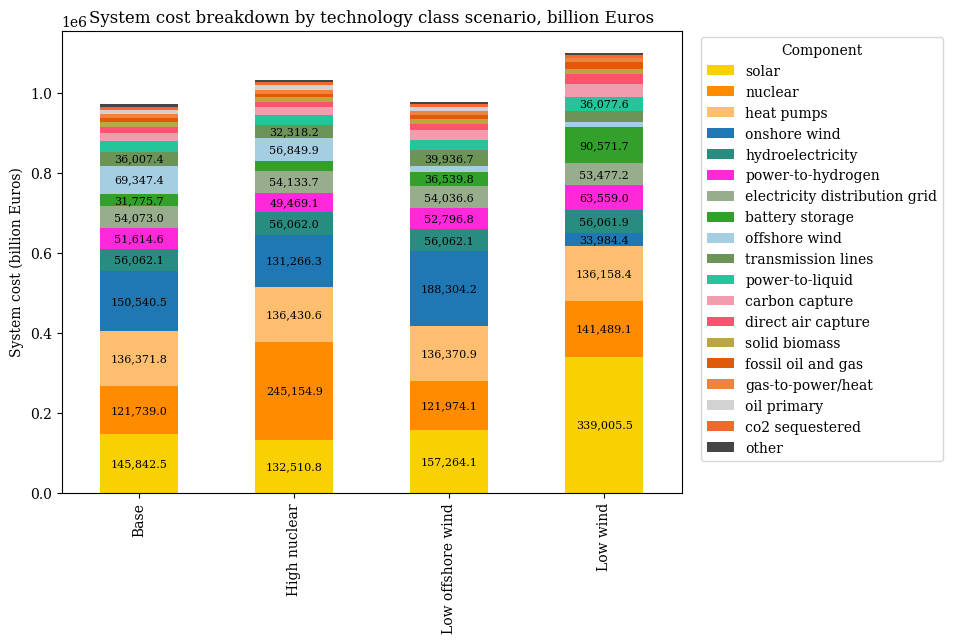

In [76]:
plot_system_cost_compare(n, [sample_base_2h_irena_phs, sample_high_nuclear, sample_low_offwind, sample_low_wind], cost_divisor=1e6, figsize=(8,6), sort_components=True, annotate_thresh=0.03)

(<Axes: title={'center': 'System cost breakdown by technology class scenario, billion Euros'}, ylabel='System cost (billion Euros)'>,
                                      Base    Low wind  Low offshore wind  \
 carrier                                                                    
 solar                          127.413962  320.576901         138.835497   
 heat pumps                     136.371753  136.158425         136.370930   
 onshore wind                   116.567910    0.011811         154.331574   
 power-to-hydrogen               51.614554   63.559030          52.796801   
 electricity distribution grid   54.072965   53.477182          54.036638   
 nuclear                         15.120888   34.871002          15.355952   
 battery storage                 31.775714   90.571658          36.539847   
 power-to-liquid                 25.928521   36.077615          26.708412   
 offshore wind                   55.844813    0.005048           0.005258   
 carbon capture    

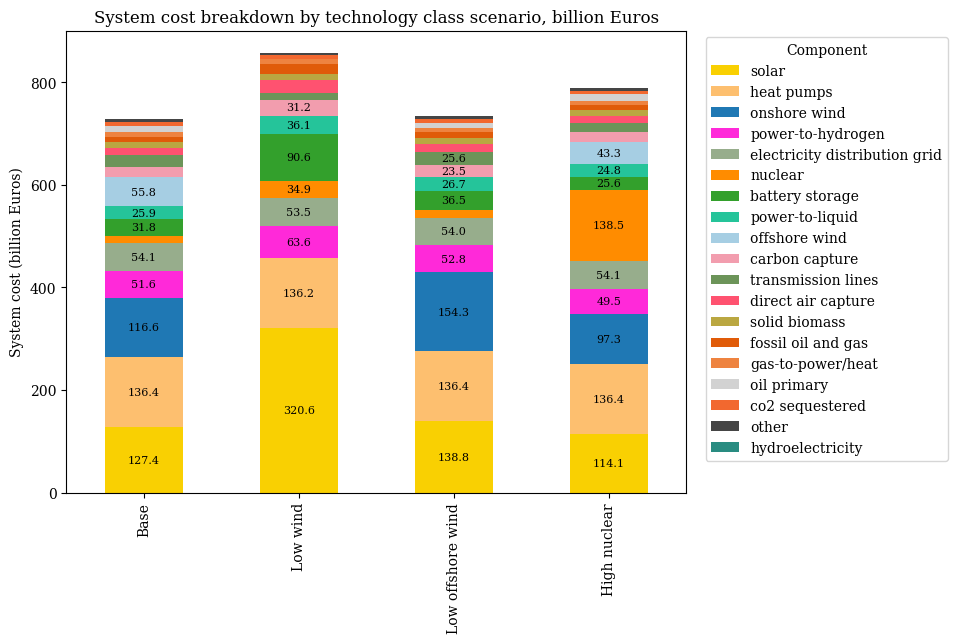

In [77]:
plot_system_cost_compare(n, [sample_base_2h_irena_phs, sample_low_wind, sample_low_offwind, sample_high_nuclear, sample_low_offwind, sample_low_wind], method="expanded", cost_divisor=1e9, figsize=(8,6), sort_components=True, annotate_thresh=0.03)